# Cell 1 — optional installs

In [3]:
# Uncomment if needed
# !pip install pandas openpyxl scikit-learn optuna xgboost catboost torch matplotlib

# Cell 2 — imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.base import clone

import optuna

# External models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# PyTorch for PINN
import torch
import torch.nn as nn
import torch.optim as optim

# Cell 3 — config

In [2]:
# =========================
# USER SETTINGS
# =========================

FILE_PATH = "database.xlsx"
SHEET_NAME = 0

# ---- Match your Excel file exactly ----
PRESSURE_COL = "P"
TEMPERATURE_COL = "T"
ALCLAY_COL = "Al/clay"
TARGET_COL = "C"

# Optional extra raw feature columns from your current data
OPTIONAL_RAW_FEATURES = []

RANDOM_STATE = 42
TEST_SIZE = 0.20
CAL_SIZE_FROM_TRAIN = 0.20

# OOD settings
PRESSURE_Q_LOW = 0.15
PRESSURE_Q_HIGH = 0.85

# Optuna settings
N_TRIALS_BASELINES = 25
N_TRIALS_PINN = 25

# Torch settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

Using device: cpu


# Cell 4 — helpers

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def conformal_interval_from_calibration(y_cal, y_cal_pred, y_pred_test, alpha=0.10):
    resid = np.abs(y_cal - y_cal_pred)
    q = np.quantile(resid, 1 - alpha, method="higher" if hasattr(np, "quantile") else None)
    lower = y_pred_test - q
    upper = y_pred_test + q
    return lower, upper, q


def interval_metrics(y_true, lower, upper):
    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    width = np.mean(upper - lower)
    return {
        "Coverage": coverage,
        "AvgWidth": width
    }


def make_physics_features(df: pd.DataFrame,
                          pressure_col: str,
                          temp_col: str,
                          alclay_col: str) -> pd.DataFrame:
    out = df.copy()

    P = out[pressure_col].astype(float)
    T = out[temp_col].astype(float)
    A = out[alclay_col].astype(float)

    eps = 1e-8

    # Raw variables kept
    out["inv_T"] = 1.0 / (T + eps)
    out["log1p_P"] = np.log1p(P)
    out["P_over_T"] = P / (T + eps)
    out["P_sat_10"] = P / (P + 10.0 + eps)
    out["log1p_A"] = np.log1p(A)
    out["P_over_A"] = P / (A + eps)
    out["A_over_T"] = A / (T + eps)
    out["P_times_invT"] = P * (1.0 / (T + eps))
    out["P_times_logA"] = P * np.log1p(A)
    out["A_over_1plusP"] = A / (1.0 + P + eps)

    return out


def get_feature_columns():
    base = [PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL] + OPTIONAL_RAW_FEATURES
    derived = [
        "inv_T",
        "log1p_P",
        "P_over_T",
        "P_sat_10",
        "log1p_A",
        "P_over_A",
        "A_over_T",
        "P_times_invT",
        "P_times_logA",
        "A_over_1plusP",
    ]
    return base + derived

# Cell 5 — load data

In [4]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

required_cols = [PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL, TARGET_COL] + OPTIONAL_RAW_FEATURES
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nAvailable columns: {list(df.columns)}")

df = df[required_cols].copy()
df = df.dropna().reset_index(drop=True)

print(df.head())
print("\nShape:", df.shape)

          P    T  Al/clay         C
0  0.751758  473       10  0.075233
1  1.052262  473       10  0.101982
2  1.950279  473       10  0.135405
3  2.326407  473       10  0.175530
4  3.972563  473       10  0.234019

Shape: (191, 4)


# Cell 6 — create physics-derived features

In [5]:
df_feat = make_physics_features(df, PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL)
feature_cols = get_feature_columns()

X_all = df_feat[feature_cols].copy()
y_all = df_feat[TARGET_COL].astype(float).values

print("Feature columns:")
print(feature_cols)
print("\nX shape:", X_all.shape, "y shape:", y_all.shape)

Feature columns:
['P', 'T', 'Al/clay', 'inv_T', 'log1p_P', 'P_over_T', 'P_sat_10', 'log1p_A', 'P_over_A', 'A_over_T', 'P_times_invT', 'P_times_logA', 'A_over_1plusP']

X shape: (191, 13) y shape: (191,)


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- GLOBAL STYLE (NO LaTeX, only mathtext) ----------
mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "stix",
    "font.family": "Times New Roman",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

FIGDIR = "figures_PI_HySPAC"
os.makedirs(FIGDIR, exist_ok=True)

# Safe copy for plotting
df_plot = df_feat.copy()

# Safe target name for plotting if your column has special chars
target_safe = "Hydrogen_Capacity"
df_plot[target_safe] = df_plot[TARGET_COL].astype(float)

# Nice labels
LABELS = {
    "P": "Pressure, $P$ (kPa)",
    "T": "Temperature, $T$ (K)",
    "Al/clay": "Al/clay ratio, $A$",
    "inv_T": r"$1/T$",
    "log1p_P": r"$\log(1+P)$",
    "P_over_T": r"$P/T$",
    "P_sat_10": r"$P/(P+10)$",
    "log1p_A": r"$\log(1+A)$",
    "P_over_A": r"$P/A$",
    "A_over_T": r"$A/T$",
    "P_times_invT": r"$P\cdot(1/T)$",
    "P_times_logA": r"$P\cdot\log(1+A)$",
    "A_over_1plusP": r"$A/(1+P)$",
    target_safe: r" $C$ (mmol STP/g)"
}

[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' object has no attribute 'collections'
[warn] KDE failed: 'QuadContourSet' ob

Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\cdot' [U+22c5], substituting with a dummy symbol.
Font 'rm' does not ha

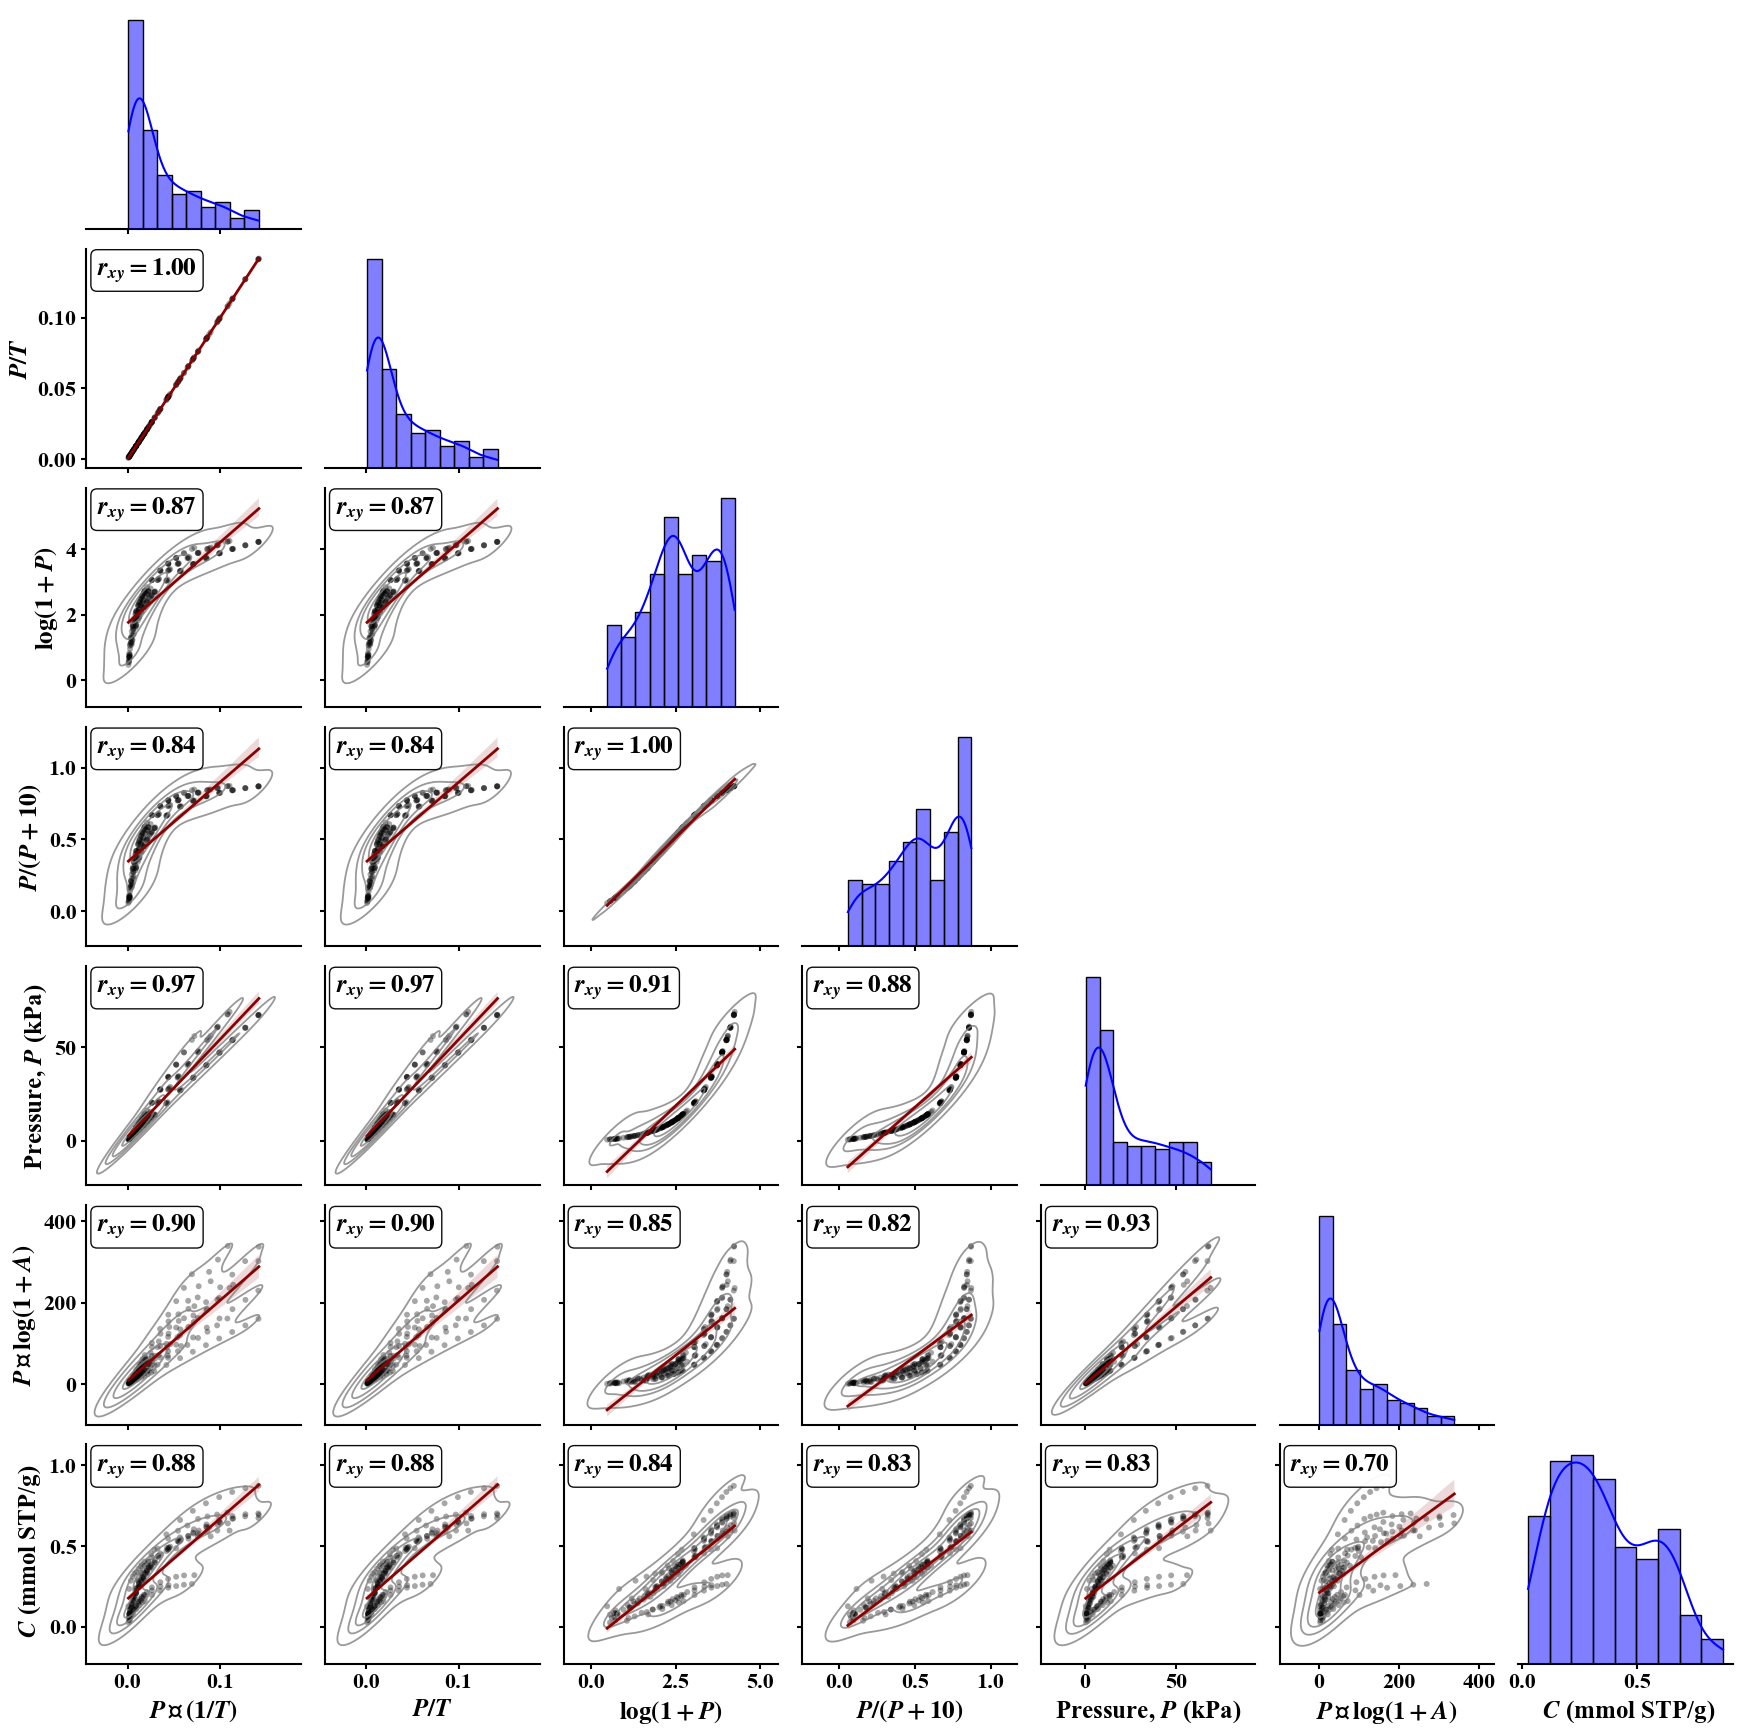

In [14]:
# ---------- PAIRPLOT WITH CONTOURS + REGRESSION + r_xy ----------
pairplot_top_k = 6  # choose top correlated features with target

corr = df_plot[feature_cols + [target_safe]].corr(method="pearson")
corr_to_y = corr[target_safe].drop(target_safe).abs().sort_values(ascending=False)
top_k = corr_to_y.head(pairplot_top_k).index.tolist()
pp_cols = top_k + [target_safe]

def lower_func(x, y, **kwargs):
    ax = plt.gca()
    ax.scatter(x, y, s=18, alpha=0.35, color="black", edgecolor="none")

    try:
        sns.kdeplot(
            x=x, y=y,
            levels=5,
            color="gray",
            linewidths=1.3,
            alpha=0.8,
            ax=ax
        )
    except Exception as e:
        print(f"[warn] KDE failed: {e}")

    sns.regplot(
        x=x, y=y, scatter=False,
        line_kws={"color": "darkred", "linewidth": 2.0},
        ax=ax
    )

    r_val = np.corrcoef(x, y)[0, 1]
    ax.text(
        0.05, 0.90, f"$r_{{xy}}={r_val:.2f}$",
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="center",
        color="black",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=1.0, alpha=0.95)
    )

g = sns.PairGrid(df_plot[pp_cols], corner=True, diag_sharey=False)
g.map_lower(lower_func)
g.map_diag(sns.histplot, kde=True, color="blue")

for ax in g.axes.flatten():
    if ax is not None:
        xl = ax.get_xlabel()
        yl = ax.get_ylabel()

        if xl:
            ax.set_xlabel(LABELS.get(xl, xl), fontsize=18, color="black", fontweight="bold")
        if yl:
            ax.set_ylabel(LABELS.get(yl, yl), fontsize=18, color="black", fontweight="bold")

        ax.tick_params(axis="both", labelsize=16, width=1.5, colors="black", labelcolor="black")
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

g.savefig(f"{FIGDIR}/pairplot_contours_corr_bold.png", bbox_inches="tight", dpi=300)
g.savefig(f"{FIGDIR}/pairplot_contours_corr_bold.pdf", bbox_inches="tight", dpi=300)
plt.show()
plt.close(g.fig)

In [11]:
# ---------- 6) SUMMARY STATISTICS FOR ALL NUMERIC VARIABLES ----------

import numpy as np
import pandas as pd

def summary_stats_all(
    df,
    cols=None,
    round_digits=3,
    include_skew=True,
    include_cv=True,
    include_missing=True,
    include_unique=True
):
    # If no columns are passed, use all numeric columns
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Keep only columns that actually exist
    cols = [c for c in cols if c in df.columns]

    # Base descriptive statistics
    stats = df[cols].describe(percentiles=[0.25, 0.5, 0.75]).T

    stats = stats.rename(columns={
        "25%": "Q1 (25th)",
        "50%": "Median",
        "75%": "Q3 (75th)",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "max": "Max",
        "count": "Count"
    })

    keep_cols = ["Count", "Min", "Q1 (25th)", "Median", "Q3 (75th)", "Max", "Mean", "Std"]
    stats = stats[keep_cols]

    # Optional additions
    if include_skew:
        stats["Skewness"] = df[cols].skew()

    if include_cv:
        mean_vals = df[cols].mean()
        std_vals = df[cols].std()
        stats["CoV"] = std_vals / mean_vals.replace(0, np.nan)

    if include_missing:
        stats["Missing"] = df[cols].isna().sum()
        stats["Missing (%)"] = 100 * df[cols].isna().mean()

    if include_unique:
        stats["Unique"] = df[cols].nunique()

    return stats.round(round_digits)


# ------------------------------------------
# OPTION 1: summary for raw variables only
# ------------------------------------------
raw_summary_cols = [PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL, TARGET_COL] + OPTIONAL_RAW_FEATURES
raw_summary_cols = [c for c in raw_summary_cols if c in df.columns]

stats_raw_df = summary_stats_all(df, cols=raw_summary_cols)

print("\nSummary statistics: raw variables\n")
print(stats_raw_df)

stats_raw_df.to_excel(f"{FIGDIR}/summary_statistics_raw.xlsx")
stats_raw_df.to_csv(f"{FIGDIR}/summary_statistics_raw.csv")


# ------------------------------------------
# OPTION 2: summary for raw + engineered variables
# ------------------------------------------
all_summary_cols = feature_cols + [target_safe]
all_summary_cols = [c for c in all_summary_cols if c in df_plot.columns]

stats_all_df = summary_stats_all(df_plot, cols=all_summary_cols)

print("\nSummary statistics: raw + physics-guided variables\n")
print(stats_all_df)

stats_all_df.to_excel(f"{FIGDIR}/summary_statistics_all_variables.xlsx")
stats_all_df.to_csv(f"{FIGDIR}/summary_statistics_all_variables.csv")


Summary statistics: raw variables

         Count      Min  Q1 (25th)   Median  Q3 (75th)      Max     Mean  \
P        191.0    0.610      5.888   12.977     33.967   68.702   21.349   
T        191.0  473.000    473.000  623.000    773.000  773.000  613.576   
Al/clay  191.0   10.000     10.000   30.000     90.000  150.000   68.115   
C        191.0    0.027      0.187    0.319      0.531    0.871    0.357   

             Std  Skewness    CoV  Missing  Missing (%)  Unique  
P         19.469     0.916  0.912        0          0.0     190  
T        121.786     0.116  0.198        0          0.0       3  
Al/clay   53.750     0.404  0.789        0          0.0       4  
C          0.204     0.421  0.573        0          0.0     190  

Summary statistics: raw + physics-guided variables

                   Count      Min  Q1 (25th)   Median  Q3 (75th)      Max  \
P                  191.0    0.610      5.888   12.977     33.967   68.702   
T                  191.0  473.000    473.000  

# Cell 7 — IID split + conformal split

In [12]:
X_train_full, X_test_iid, y_train_full, y_test_iid = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full, y_train_full,
    test_size=CAL_SIZE_FROM_TRAIN,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, len(y_train))
print("Calibration:", X_cal.shape, len(y_cal))
print("IID Test:", X_test_iid.shape, len(y_test_iid))

Train: (121, 13) 121
Calibration: (31, 13) 31
IID Test: (39, 13) 39


# Cell 8 — OOD split builders

In [13]:
def make_ood_splits(df_full: pd.DataFrame) -> Dict[str, Tuple[pd.DataFrame, np.ndarray, pd.DataFrame, np.ndarray]]:
    splits = {}

    # 1) Pressure high-tail OOD
    q_high = df_full[PRESSURE_COL].quantile(PRESSURE_Q_HIGH)
    test_mask = df_full[PRESSURE_COL] >= q_high
    train_mask = ~test_mask
    splits["OOD_pressure_high"] = (
        df_full.loc[train_mask, feature_cols],
        df_full.loc[train_mask, TARGET_COL].values,
        df_full.loc[test_mask, feature_cols],
        df_full.loc[test_mask, TARGET_COL].values
    )

    # 2) Pressure low-tail OOD
    q_low = df_full[PRESSURE_COL].quantile(PRESSURE_Q_LOW)
    test_mask = df_full[PRESSURE_COL] <= q_low
    train_mask = ~test_mask
    splits["OOD_pressure_low"] = (
        df_full.loc[train_mask, feature_cols],
        df_full.loc[train_mask, TARGET_COL].values,
        df_full.loc[test_mask, feature_cols],
        df_full.loc[test_mask, TARGET_COL].values
    )

    # 3) Temperature max-group holdout
    temp_hold = df_full[TEMPERATURE_COL].max()
    test_mask = df_full[TEMPERATURE_COL] == temp_hold
    if test_mask.sum() > 0 and (~test_mask).sum() > 0:
        splits["OOD_temp_max_group"] = (
            df_full.loc[~test_mask, feature_cols],
            df_full.loc[~test_mask, TARGET_COL].values,
            df_full.loc[test_mask, feature_cols],
            df_full.loc[test_mask, TARGET_COL].values
        )

    # 4) Al/clay max-group holdout
    aclay_hold = df_full[ALCLAY_COL].max()
    test_mask = df_full[ALCLAY_COL] == aclay_hold
    if test_mask.sum() > 0 and (~test_mask).sum() > 0:
        splits["OOD_alclay_max_group"] = (
            df_full.loc[~test_mask, feature_cols],
            df_full.loc[~test_mask, TARGET_COL].values,
            df_full.loc[test_mask, feature_cols],
            df_full.loc[test_mask, TARGET_COL].values
        )

    return splits


ood_splits = make_ood_splits(df_feat)
print("OOD splits:", list(ood_splits.keys()))
for k, v in ood_splits.items():
    print(k, "train:", v[0].shape, "test:", v[2].shape)

OOD splits: ['OOD_pressure_high', 'OOD_pressure_low', 'OOD_temp_max_group', 'OOD_alclay_max_group']
OOD_pressure_high train: (162, 13) test: (29, 13)
OOD_pressure_low train: (162, 13) test: (29, 13)
OOD_temp_max_group train: (134, 13) test: (57, 13)
OOD_alclay_max_group train: (148, 13) test: (43, 13)


# Cell 9 — baseline model factories

In [14]:
def build_adaboost(params):
    base = DecisionTreeRegressor(
        max_depth=params["max_depth"],
        random_state=RANDOM_STATE
    )
    return AdaBoostRegressor(
        estimator=base,
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        loss=params["loss"],
        random_state=RANDOM_STATE
    )

def build_gbm(params):
    return GradientBoostingRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        subsample=params["subsample"],
        random_state=RANDOM_STATE
    )

def build_catboost(params):
    return CatBoostRegressor(
        iterations=params["iterations"],
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],
        loss_function="RMSE",
        eval_metric="RMSE",
        verbose=False,
        random_seed=RANDOM_STATE
    )

def build_xgboost(params):
    return XGBRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    )

# Cell 10 — Optuna objectives for baselines

In [15]:
def objective_adaboost(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 6),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        "loss": trial.suggest_categorical("loss", ["linear", "square", "exponential"])
    }
    model = build_adaboost(params)
    model.fit(X_train, y_train)
    pred = model.predict(X_cal)
    return rmse(y_cal, pred)


def objective_gbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 6),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }
    model = build_gbm(params)
    model.fit(X_train, y_train)
    pred = model.predict(X_cal)
    return rmse(y_cal, pred)


def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
    }
    model = build_catboost(params)
    model.fit(X_train, y_train)
    pred = model.predict(X_cal)
    return rmse(y_cal, pred)


def objective_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }
    model = build_xgboost(params)
    model.fit(X_train, y_train)
    pred = model.predict(X_cal)
    return rmse(y_cal, pred)

# Cell 11 — tune baselines

In [16]:
baseline_studies = {}

for name, objective in {
    "AdaBoost": objective_adaboost,
    "GBM": objective_gbm,
    "CatBoost": objective_catboost,
    "XGBoost": objective_xgboost
}.items():
    print(f"Tuning {name}...")
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_BASELINES, show_progress_bar=False)
    baseline_studies[name] = study
    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)
    print("-" * 80)

[I 2026-03-30 12:38:43,665] A new study created in memory with name: no-name-dbb32981-1af5-4d1b-834f-06f90be740be


Tuning AdaBoost...


[I 2026-03-30 12:38:44,350] Trial 0 finished with value: 0.0722892891629754 and parameters: {'max_depth': 3, 'n_estimators': 478, 'learning_rate': 0.09454306819536169, 'loss': 'linear'}. Best is trial 0 with value: 0.0722892891629754.
[I 2026-03-30 12:38:44,861] Trial 1 finished with value: 0.10544856243675808 and parameters: {'max_depth': 1, 'n_estimators': 440, 'learning_rate': 0.041917115166952006, 'loss': 'exponential'}. Best is trial 0 with value: 0.0722892891629754.
[I 2026-03-30 12:38:45,090] Trial 2 finished with value: 0.06323749395343446 and parameters: {'max_depth': 5, 'n_estimators': 145, 'learning_rate': 0.003095566460242371, 'loss': 'exponential'}. Best is trial 2 with value: 0.06323749395343446.
[I 2026-03-30 12:38:45,370] Trial 3 finished with value: 0.07631943874260559 and parameters: {'max_depth': 3, 'n_estimators': 181, 'learning_rate': 0.044809759182149515, 'loss': 'exponential'}. Best is trial 2 with value: 0.06323749395343446.
[I 2026-03-30 12:38:45,893] Trial 4 f

Best RMSE: 0.04608213936169297
Best params: {'max_depth': 6, 'n_estimators': 395, 'learning_rate': 0.025157908751068027, 'loss': 'linear'}
--------------------------------------------------------------------------------
Tuning GBM...


[I 2026-03-30 12:38:57,012] Trial 1 finished with value: 0.025116902317991754 and parameters: {'n_estimators': 76, 'learning_rate': 0.13983740016490973, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 1, 'subsample': 0.9849549260809971}. Best is trial 1 with value: 0.025116902317991754.
[I 2026-03-30 12:38:57,285] Trial 2 finished with value: 0.07949078940416654 and parameters: {'n_estimators': 425, 'learning_rate': 0.0033572967053517922, 'max_depth': 2, 'min_samples_split': 5, 'min_samples_leaf': 4, 'subsample': 0.762378215816119}. Best is trial 1 with value: 0.025116902317991754.
[I 2026-03-30 12:38:57,462] Trial 3 finished with value: 0.06999136401516387 and parameters: {'n_estimators': 244, 'learning_rate': 0.005265139631677754, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.6831809216468459}. Best is trial 1 with value: 0.025116902317991754.
[I 2026-03-30 12:38:57,602] Trial 4 finished with value: 0.03307617230860486 and parameters: {'n_

...

[I 2026-03-30 12:39:02,853] Trial 0 finished with value: 0.026474307298698554 and parameters: {'iterations': 362, 'learning_rate': 0.22648248189516848, 'depth': 8, 'l2_leaf_reg': 12.374511199743695}. Best is trial 0 with value: 0.026474307298698554.
[I 2026-03-30 12:39:02,976] Trial 1 finished with value: 0.1451031708539033 and parameters: {'iterations': 209, 'learning_rate': 0.0024345423962016913, 'depth': 3, 'l2_leaf_reg': 17.457346769723767}. Best is trial 0 with value: 0.026474307298698554.
[I 2026-03-30 12:39:03,235] Trial 2 finished with value: 0.02439689935226774 and parameters: {'iterations': 521, 'learning_rate': 0.05675206026988748, 'depth': 3, 'l2_leaf_reg': 19.428287191077892}. Best is trial 2 with value: 0.02439689935226774.
[I 2026-03-30 12:39:03,606] Trial 3 finished with value: 0.057361353010064446 and parameters: {'iterations': 683, 'learning_rate': 0.0033572967053517922, 'depth': 4, 'l2_leaf_reg': 4.484685687215243}. Best is trial 2 with value: 0.02439689935226774.
[I

Best RMSE: 0.01581938177846353
Best params: {'iterations': 419, 'learning_rate': 0.08810003129071789, 'depth': 4, 'l2_leaf_reg': 10.770454329858621}
--------------------------------------------------------------------------------
Tuning XGBoost...


[I 2026-03-30 12:39:18,391] Trial 1 finished with value: 0.06056876886470232 and parameters: {'n_estimators': 521, 'learning_rate': 0.05675206026988748, 'max_depth': 2, 'min_child_weight': 9.72918866945795, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 0 with value: 0.05016205933763195.
[I 2026-03-30 12:39:18,528] Trial 2 finished with value: 0.062425627689505964 and parameters: {'n_estimators': 313, 'learning_rate': 0.0199473547030745, 'max_depth': 5, 'min_child_weight': 3.6210622617823773, 'subsample': 0.8059264473611898, 'colsample_bytree': 0.569746930326021, 'reg_alpha': 1.4607232426760908, 'reg_lambda': 1.8318092164684585}. Best is trial 0 with value: 0.05016205933763195.
[I 2026-03-30 12:39:18,644] Trial 3 finished with value: 0.08696061075766842 and parameters: {'n_estimators': 419, 'learning_rate': 0.08810003129071789, 'max_depth': 3, 'min_child_weight': 5.62810994572250

[I 2026-03-30 12:39:22,772] Trial 22 finished with value: 0.04958980951707828 and parameters: {'n_estimators': 557, 'learning_rate': 0.06878023771479534, 'max_depth': 7, 'min_child_weight': 5.150315019808271, 'subsample': 0.7643403168148073, 'colsample_bytree': 0.7646708099678055, 'reg_alpha': 0.47780877621157214, 'reg_lambda': 4.225493329878118}. Best is trial 21 with value: 0.03178288218022377.
[I 2026-03-30 12:39:23,020] Trial 23 finished with value: 0.04319119494071907 and parameters: {'n_estimators': 739, 'learning_rate': 0.16659482726479083, 'max_depth': 7, 'min_child_weight': 3.006780874448955, 'subsample': 0.9151333750174545, 'colsample_bytree': 0.6881921632189142, 'reg_alpha': 0.4398194204782109, 'reg_lambda': 3.9303201625118387}. Best is trial 21 with value: 0.03178288218022377.
[I 2026-03-30 12:39:23,259] Trial 24 finished with value: 0.06435260881062323 and parameters: {'n_estimators': 573, 'learning_rate': 0.030921266221942238, 'max_depth': 8, 'min_child_weight': 7.2093494

Best RMSE: 0.03178288218022377
Best params: {'n_estimators': 574, 'learning_rate': 0.1717634204671842, 'max_depth': 7, 'min_child_weight': 5.690791417214452, 'subsample': 0.7594126937433106, 'colsample_bytree': 0.6897389464321348, 'reg_alpha': 0.07510605812843618, 'reg_lambda': 3.9873167919368244}
--------------------------------------------------------------------------------


# Cell 12 — rebuild tuned baselines on train+cal

In [17]:
X_traincal = pd.concat([X_train, X_cal], axis=0)
y_traincal = np.concatenate([y_train, y_cal])

baseline_models = {
    "AdaBoost": build_adaboost(baseline_studies["AdaBoost"].best_params),
    "GBM": build_gbm(baseline_studies["GBM"].best_params),
    "CatBoost": build_catboost(baseline_studies["CatBoost"].best_params),
    "XGBoost": build_xgboost(baseline_studies["XGBoost"].best_params),
}

for name, model in baseline_models.items():
    model.fit(X_traincal, y_traincal)

print("All baseline models trained on train+cal.")

All baseline models trained on train+cal.


# Cell 13 — PINN dataset prep

In [18]:
# Separate scaler for PINN
scaler_X_pinn = StandardScaler()
scaler_y_pinn = StandardScaler()

X_train_np = X_train.values.astype(np.float32)
X_cal_np = X_cal.values.astype(np.float32)
X_traincal_np = X_traincal.values.astype(np.float32)
X_test_iid_np = X_test_iid.values.astype(np.float32)

y_train_np = y_train.reshape(-1, 1).astype(np.float32)
y_cal_np = y_cal.reshape(-1, 1).astype(np.float32)
y_traincal_np = y_traincal.reshape(-1, 1).astype(np.float32)
y_test_iid_np = y_test_iid.reshape(-1, 1).astype(np.float32)

X_train_scaled = scaler_X_pinn.fit_transform(X_train_np)
X_cal_scaled = scaler_X_pinn.transform(X_cal_np)
X_traincal_scaled = scaler_X_pinn.fit_transform(X_traincal_np)  # refit on train+cal for final model
X_test_iid_scaled = scaler_X_pinn.transform(X_test_iid_np)

y_train_scaled = scaler_y_pinn.fit_transform(y_train_np)
y_cal_scaled = scaler_y_pinn.transform(y_cal_np)
y_traincal_scaled = scaler_y_pinn.fit_transform(y_traincal_np)
y_test_iid_scaled = scaler_y_pinn.transform(y_test_iid_np)

pressure_idx = feature_cols.index(PRESSURE_COL)
temperature_idx = feature_cols.index(TEMPERATURE_COL)

print("Pressure index:", pressure_idx)
print("Temperature index:", temperature_idx)

Pressure index: 0
Temperature index: 1


# Cell 14 — PINN model

In [19]:
class PINNRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_hidden=3, dropout=0.0, activation="tanh"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU
        elif activation == "gelu":
            act = nn.GELU
        else:
            act = nn.Tanh

        layers = []
        in_dim = input_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(act())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Cell 15 — physics-informed loss

In [20]:
def pinn_loss(model,
              x,
              y,
              pressure_idx,
              temperature_idx,
              lambda_p=1.0,
              lambda_t=1.0,
              lambda_sat=0.1,
              lambda_nonneg=1.0):
    x = x.clone().detach().requires_grad_(True)
    y_pred = model(x)

    data_loss = nn.MSELoss()(y_pred, y)

    grads = torch.autograd.grad(
        outputs=y_pred,
        inputs=x,
        grad_outputs=torch.ones_like(y_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    dC_dP = grads[:, pressure_idx:pressure_idx+1]
    dC_dT = grads[:, temperature_idx:temperature_idx+1]

    # Pressure monotonicity: dC/dP >= 0
    loss_p = torch.mean(torch.relu(-dC_dP) ** 2)

    # Temperature monotonicity: dC/dT <= 0
    loss_t = torch.mean(torch.relu(dC_dT) ** 2)

    # Saturation in pressure: d2C/dP2 <= 0
    d2 = torch.autograd.grad(
        outputs=dC_dP,
        inputs=x,
        grad_outputs=torch.ones_like(dC_dP),
        create_graph=True,
        retain_graph=True
    )[0]
    d2C_dP2 = d2[:, pressure_idx:pressure_idx+1]
    loss_sat = torch.mean(torch.relu(d2C_dP2) ** 2)

    # Non-negative prediction in original space is approximate here.
    # Since y is scaled, we softly enforce lower bounded predictions in scaled space near min(y)
    y_min_scaled = y.min().detach()
    loss_nonneg = torch.mean(torch.relu(y_min_scaled - y_pred) ** 2)

    total = (
        data_loss
        + lambda_p * loss_p
        + lambda_t * loss_t
        + lambda_sat * loss_sat
        + lambda_nonneg * loss_nonneg
    )

    return total, {
        "data_loss": data_loss.item(),
        "loss_p": loss_p.item(),
        "loss_t": loss_t.item(),
        "loss_sat": loss_sat.item(),
        "loss_nonneg": loss_nonneg.item(),
    }

# Cell 16 — PINN training function

In [22]:
def train_pinn_once(Xtr, ytr, Xva, yva, params, verbose=False):
    set_seed(RANDOM_STATE)

    model = PINNRegressor(
        input_dim=Xtr.shape[1],
        hidden_dim=params["hidden_dim"],
        n_hidden=params["n_hidden"],
        dropout=params["dropout"],
        activation=params["activation"]
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=DEVICE)
    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=DEVICE)
    yva_t = torch.tensor(yva, dtype=torch.float32, device=DEVICE)

    best_val = np.inf
    best_state = None
    patience = params["patience"]
    wait = 0

    history = []

    for epoch in range(params["epochs"]):
        model.train()
        optimizer.zero_grad()

        total_loss, loss_parts = pinn_loss(
            model, Xtr_t, ytr_t,
            pressure_idx=pressure_idx,
            temperature_idx=temperature_idx,
            lambda_p=params["lambda_p"],
            lambda_t=params["lambda_t"],
            lambda_sat=params["lambda_sat"],
            lambda_nonneg=params["lambda_nonneg"]
        )
        total_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            yva_pred = model(Xva_t)
            val_loss = nn.MSELoss()(yva_pred, yva_t).item()

        history.append((epoch, total_loss.item(), val_loss))

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val, history

# Cell 17 — Optuna objective for PINN

In [23]:
def objective_pinn(trial):
    params = {
        "hidden_dim": trial.suggest_categorical("hidden_dim", [32, 64, 128, 256]),
        "n_hidden": trial.suggest_int("n_hidden", 2, 5),
        "dropout": trial.suggest_float("dropout", 0.0, 0.3),
        "activation": trial.suggest_categorical("activation", ["tanh", "relu", "gelu"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True),
        "lambda_p": trial.suggest_float("lambda_p", 1e-4, 10.0, log=True),
        "lambda_t": trial.suggest_float("lambda_t", 1e-4, 10.0, log=True),
        "lambda_sat": trial.suggest_float("lambda_sat", 1e-5, 1.0, log=True),
        "lambda_nonneg": trial.suggest_float("lambda_nonneg", 1e-5, 1.0, log=True),
        "epochs": trial.suggest_int("epochs", 200, 1000),
        "patience": trial.suggest_int("patience", 30, 100),
    }

    model, best_val, _ = train_pinn_once(
        X_train_scaled, y_train_scaled,
        X_cal_scaled, y_cal_scaled,
        params=params,
        verbose=False
    )

    return best_val


print("Tuning PINN...")
study_pinn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_pinn.optimize(objective_pinn, n_trials=N_TRIALS_PINN, show_progress_bar=False)

print("Best PINN val MSE:", study_pinn.best_value)
print("Best PINN params:", study_pinn.best_params)

[I 2026-03-30 12:42:36,745] A new study created in memory with name: no-name-e3b252c3-feea-45e2-92aa-cddbbd052a2f


Tuning PINN...


[I 2026-03-30 12:42:39,854] Trial 0 finished with value: 0.004204315133392811 and parameters: {'hidden_dim': 64, 'n_hidden': 2, 'dropout': 0.04679835610086079, 'activation': 'relu', 'lr': 0.008148293210105292, 'weight_decay': 1.328944872286916e-08, 'lambda_p': 7.072114131472227, 'lambda_t': 1.452824663751602, 'lambda_sat': 0.00011526449540315612, 'lambda_nonneg': 8.111941985431919e-05, 'epochs': 346, 'patience': 51}. Best is trial 0 with value: 0.004204315133392811.
[I 2026-03-30 12:42:41,921] Trial 1 finished with value: 0.024537794291973114 and parameters: {'hidden_dim': 256, 'n_hidden': 2, 'dropout': 0.08764339456056544, 'activation': 'gelu', 'lr': 0.0003458705214751812, 'weight_decay': 1.217325250419405e-05, 'lambda_p': 0.09163741808778776, 'lambda_t': 0.00017070728830306665, 'lambda_sat': 0.010907475835157693, 'lambda_nonneg': 7.122305833333864e-05, 'epochs': 252, 'patience': 97}. Best is trial 0 with value: 0.004204315133392811.
[I 2026-03-30 12:42:43,918] Trial 2 finished with v

[I 2026-03-30 12:43:34,663] Trial 18 finished with value: 0.003082290291786194 and parameters: {'hidden_dim': 256, 'n_hidden': 2, 'dropout': 0.038143152602661684, 'activation': 'relu', 'lr': 0.0022035875293424613, 'weight_decay': 6.08845415838759e-05, 'lambda_p': 0.00512161295969499, 'lambda_t': 0.0010787592909094258, 'lambda_sat': 9.728032872620095e-05, 'lambda_nonneg': 3.310040833313595e-05, 'epochs': 969, 'patience': 68}. Best is trial 18 with value: 0.003082290291786194.
[I 2026-03-30 12:43:36,749] Trial 19 finished with value: 0.01612790673971176 and parameters: {'hidden_dim': 64, 'n_hidden': 2, 'dropout': 0.10252506948396509, 'activation': 'relu', 'lr': 0.0007961734121277413, 'weight_decay': 0.0011747302219789106, 'lambda_p': 0.003916962206183298, 'lambda_t': 0.0007158290232619, 'lambda_sat': 0.002588958861907838, 'lambda_nonneg': 0.0002557206597438705, 'epochs': 987, 'patience': 44}. Best is trial 18 with value: 0.003082290291786194.
[I 2026-03-30 12:43:42,516] Trial 20 finished

Best PINN val MSE: 0.0022670202888548374
Best PINN params: {'hidden_dim': 256, 'n_hidden': 2, 'dropout': 0.057526558122330256, 'activation': 'tanh', 'lr': 0.003112241184948562, 'weight_decay': 5.833566384709114e-05, 'lambda_p': 0.0006099978919664861, 'lambda_t': 8.309498651124366, 'lambda_sat': 6.0084363948801e-05, 'lambda_nonneg': 0.037100887276472434, 'epochs': 866, 'patience': 83}


# Cell 18 — retrain final PINN on train+cal

In [24]:
best_pinn_params = study_pinn.best_params.copy()

# train+cal split needs tiny validation for early stopping
X_subtrain, X_subval, y_subtrain, y_subval = train_test_split(
    X_traincal_scaled, y_traincal_scaled,
    test_size=0.15, random_state=RANDOM_STATE
)

final_pinn, final_pinn_val, pinn_history = train_pinn_once(
    X_subtrain, y_subtrain,
    X_subval, y_subval,
    params=best_pinn_params,
    verbose=False
)

print("Final PINN trained.")
print("Final validation MSE:", final_pinn_val)

Final PINN trained.
Final validation MSE: 0.006268133409321308


# Cell 19 — PINN prediction helper

In [25]:
def predict_pinn(model, X_scaled, scaler_y):
    model.eval()
    X_t = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        pred_scaled = model(X_t).cpu().numpy()
    pred = scaler_y.inverse_transform(pred_scaled).ravel()
    return pred

# Cell 20 — IID evaluation for all models

In [26]:
iid_results = []

# Baselines
for name, model in baseline_models.items():
    pred = model.predict(X_test_iid)
    m = regression_metrics(y_test_iid, pred)
    m["Model"] = name
    m["Split"] = "IID"
    iid_results.append(m)

# PINN
pred_pinn_iid = predict_pinn(final_pinn, X_test_iid_scaled, scaler_y_pinn)
m = regression_metrics(y_test_iid, pred_pinn_iid)
m["Model"] = "PINN_PI-HySPAC"
m["Split"] = "IID"
iid_results.append(m)

iid_results_df = pd.DataFrame(iid_results).sort_values(["Split", "RMSE"])
iid_results_df

,R2,RMSE,MAE,Model,Split
4,0.994325,0.016846,0.013263,PINN_PI-HySPAC,IID
2,0.993047,0.018647,0.015298,CatBoost,IID
1,0.991074,0.021127,0.016618,GBM,IID
3,0.984905,0.027474,0.022153,XGBoost,IID
0,0.978163,0.033045,0.022467,AdaBoost,IID


# Cell 21 — conformal prediction on IID test

In [27]:
conformal_results = []

# Baselines: use original calibration set
for name, study in baseline_studies.items():
    if name == "AdaBoost":
        model = build_adaboost(study.best_params)
    elif name == "GBM":
        model = build_gbm(study.best_params)
    elif name == "CatBoost":
        model = build_catboost(study.best_params)
    else:
        model = build_xgboost(study.best_params)

    model.fit(X_train, y_train)

    y_cal_pred = model.predict(X_cal)
    y_test_pred = model.predict(X_test_iid)

    lower, upper, q = conformal_interval_from_calibration(y_cal, y_cal_pred, y_test_pred, alpha=0.10)
    met = interval_metrics(y_test_iid, lower, upper)
    met["ResidualQ90"] = q
    met["Model"] = name
    met["Split"] = "IID"
    conformal_results.append(met)

# PINN conformal
# Train-only scaler for proper calibration
scaler_X_trainonly = StandardScaler().fit(X_train.values.astype(np.float32))
scaler_y_trainonly = StandardScaler().fit(y_train.reshape(-1, 1).astype(np.float32))

Xtr_s = scaler_X_trainonly.transform(X_train.values.astype(np.float32))
Xcal_s = scaler_X_trainonly.transform(X_cal.values.astype(np.float32))
Xte_s = scaler_X_trainonly.transform(X_test_iid.values.astype(np.float32))

ytr_s = scaler_y_trainonly.transform(y_train.reshape(-1, 1).astype(np.float32))
ycal_s = scaler_y_trainonly.transform(y_cal.reshape(-1, 1).astype(np.float32))

pinn_cal_model, _, _ = train_pinn_once(
    Xtr_s, ytr_s,
    Xcal_s, ycal_s,
    params=best_pinn_params,
    verbose=False
)

y_cal_pred_pinn = predict_pinn(pinn_cal_model, Xcal_s, scaler_y_trainonly)
y_test_pred_pinn = predict_pinn(pinn_cal_model, Xte_s, scaler_y_trainonly)

lower, upper, q = conformal_interval_from_calibration(y_cal, y_cal_pred_pinn, y_test_pred_pinn, alpha=0.10)
met = interval_metrics(y_test_iid, lower, upper)
met["ResidualQ90"] = q
met["Model"] = "PINN_PI-HySPAC"
met["Split"] = "IID"
conformal_results.append(met)

conformal_results_df = pd.DataFrame(conformal_results).sort_values("AvgWidth")
conformal_results_df

,Coverage,AvgWidth,ResidualQ90,Model,Split
4,0.820513,0.029404,0.014702,PINN_PI-HySPAC,IID
2,0.769231,0.047498,0.023749,CatBoost,IID
1,0.897436,0.089792,0.044896,GBM,IID
3,0.948718,0.118529,0.059265,XGBoost,IID
0,0.948718,0.119764,0.059882,AdaBoost,IID


# Cell 22 — OOD evaluation function

In [29]:
def evaluate_on_ood_split(name, Xtr, ytr, Xte, yte, baseline_best_params, pinn_params):
    rows = []

    # Baselines
    builders = {
        "AdaBoost": build_adaboost,
        "GBM": build_gbm,
        "CatBoost": build_catboost,
        "XGBoost": build_xgboost
    }

    for model_name, builder in builders.items():
        model = builder(baseline_best_params[model_name])
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        m = regression_metrics(yte, pred)
        m["Model"] = model_name
        m["Split"] = name
        rows.append(m)

    # PINN
    scX = StandardScaler()
    scy = StandardScaler()

    Xtr_np = Xtr.values.astype(np.float32)
    Xte_np = Xte.values.astype(np.float32)
    ytr_np = ytr.reshape(-1, 1).astype(np.float32)

    Xtr_s = scX.fit_transform(Xtr_np)
    Xte_s = scX.transform(Xte_np)
    ytr_s = scy.fit_transform(ytr_np)

    # small internal val split
    Xsub_tr, Xsub_va, ysub_tr, ysub_va = train_test_split(
        Xtr_s, ytr_s, test_size=0.15, random_state=RANDOM_STATE
    )

    pinn_model, _, _ = train_pinn_once(
        Xsub_tr, ysub_tr,
        Xsub_va, ysub_va,
        params=pinn_params,
        verbose=False
    )

    pred = predict_pinn(pinn_model, Xte_s, scy)
    m = regression_metrics(yte, pred)
    m["Model"] = "PINN_PI-HySPAC"
    m["Split"] = name
    rows.append(m)

    return rows

# Cell 23 — run OOD tests

In [30]:
baseline_best_params = {
    "AdaBoost": baseline_studies["AdaBoost"].best_params,
    "GBM": baseline_studies["GBM"].best_params,
    "CatBoost": baseline_studies["CatBoost"].best_params,
    "XGBoost": baseline_studies["XGBoost"].best_params,
}

ood_rows = []
for split_name, (Xtr, ytr, Xte, yte) in ood_splits.items():
    rows = evaluate_on_ood_split(
        split_name, Xtr, ytr, Xte, yte,
        baseline_best_params=baseline_best_params,
        pinn_params=best_pinn_params
    )
    ood_rows.extend(rows)

ood_results_df = pd.DataFrame(ood_rows).sort_values(["Split", "RMSE"])
ood_results_df

,R2,RMSE,MAE,Model,Split
15,0.985252,0.024386,0.019671,AdaBoost,OOD_alclay_max_group
16,0.979356,0.028852,0.022006,GBM,OOD_alclay_max_group
17,0.970323,0.034593,0.027072,CatBoost,OOD_alclay_max_group
18,0.969978,0.034794,0.026459,XGBoost,OOD_alclay_max_group
19,0.852693,0.077072,0.065485,PINN_PI-HySPAC,OOD_alclay_max_group
4,0.958267,0.027721,0.022368,PINN_PI-HySPAC,OOD_pressure_high
2,0.917143,0.039060,0.034479,CatBoost,OOD_pressure_high
3,0.797619,0.061045,0.047409,XGBoost,OOD_pressure_high
0,0.762340,0.066152,0.049412,AdaBoost,OOD_pressure_high
1,0.574221,0.088544,0.078446,GBM,OOD_pressure_high


# Cell 24 — combined summary table

In [31]:
summary_df = pd.concat([
    iid_results_df[["Model", "Split", "R2", "RMSE", "MAE"]],
    ood_results_df[["Model", "Split", "R2", "RMSE", "MAE"]],
], axis=0).reset_index(drop=True)

summary_df

,Model,Split,R2,RMSE,MAE
0,PINN_PI-HySPAC,IID,0.994325,0.016846,0.013263
1,CatBoost,IID,0.993047,0.018647,0.015298
2,GBM,IID,0.991074,0.021127,0.016618
3,XGBoost,IID,0.984905,0.027474,0.022153
4,AdaBoost,IID,0.978163,0.033045,0.022467
5,AdaBoost,OOD_alclay_max_group,0.985252,0.024386,0.019671
6,GBM,OOD_alclay_max_group,0.979356,0.028852,0.022006
7,CatBoost,OOD_alclay_max_group,0.970323,0.034593,0.027072
8,XGBoost,OOD_alclay_max_group,0.969978,0.034794,0.026459
9,PINN_PI-HySPAC,OOD_alclay_max_group,0.852693,0.077072,0.065485


# Cell 25 — best model by split

In [32]:
best_by_split = summary_df.sort_values(["Split", "RMSE"]).groupby("Split").first().reset_index()
best_by_split

,Split,Model,R2,RMSE,MAE
0,IID,PINN_PI-HySPAC,0.994325,0.016846,0.013263
1,OOD_alclay_max_group,AdaBoost,0.985252,0.024386,0.019671
2,OOD_pressure_high,PINN_PI-HySPAC,0.958267,0.027721,0.022368
3,OOD_pressure_low,PINN_PI-HySPAC,0.799630,0.025762,0.020780
4,OOD_temp_max_group,PINN_PI-HySPAC,-0.553334,0.142459,0.129784


# Cell 26 — simple plots

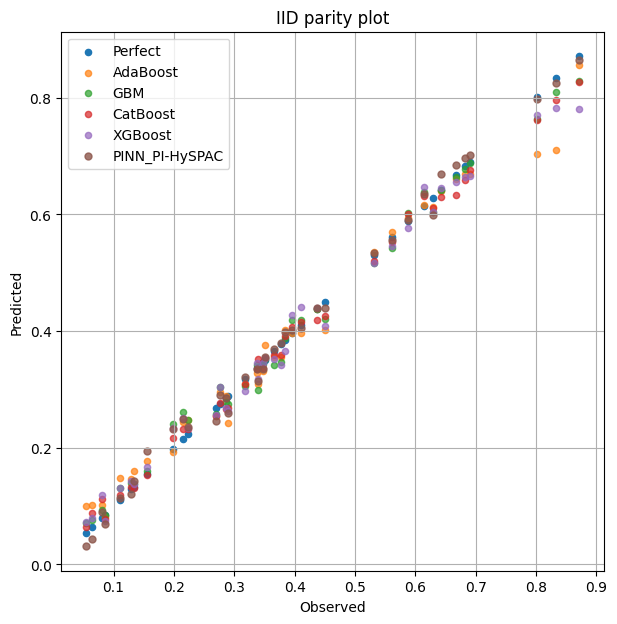

In [33]:
# IID parity plot for all models
plt.figure(figsize=(7, 7))
plt.scatter(y_test_iid, y_test_iid, s=20, label="Perfect")
for name, model in baseline_models.items():
    pred = model.predict(X_test_iid)
    plt.scatter(y_test_iid, pred, s=20, alpha=0.7, label=name)

plt.scatter(y_test_iid, pred_pinn_iid, s=25, alpha=0.8, label="PINN_PI-HySPAC")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("IID parity plot")
plt.legend()
plt.grid(True)
plt.show()

# Cell 27 — plot PINN training history

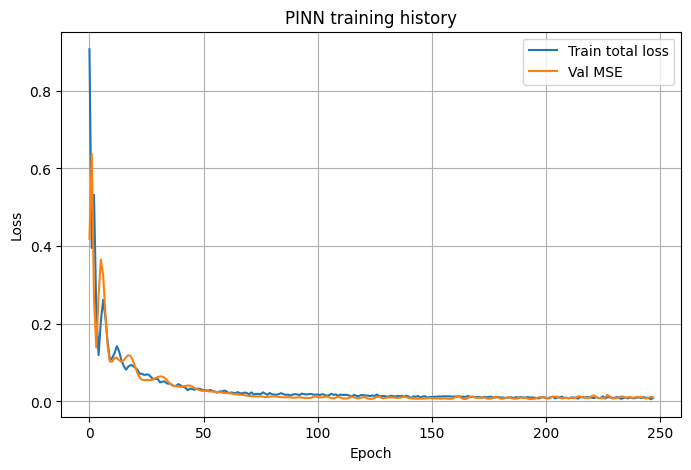

In [34]:
hist_df = pd.DataFrame(pinn_history, columns=["epoch", "train_total_loss", "val_mse"])
plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_total_loss"], label="Train total loss")
plt.plot(hist_df["epoch"], hist_df["val_mse"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN training history")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
with pd.ExcelWriter("PI_HySPAC_results.xlsx", engine="openpyxl") as writer:
    iid_results_df.to_excel(writer, sheet_name="IID_metrics", index=False)
    conformal_results_df.to_excel(writer, sheet_name="Conformal_IID", index=False)
    ood_results_df.to_excel(writer, sheet_name="OOD_metrics", index=False)
    summary_df.to_excel(writer, sheet_name="All_metrics", index=False)
    best_by_split.to_excel(writer, sheet_name="Best_by_split", index=False)

print("Saved: PI_HySPAC_results.xlsx")

Saved: PI_HySPAC_results.xlsx


# Cell A2 — imports for explainability and plotting

In [36]:
import os
import shap
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

FIG_DIR = "figures_PI_HySPAC"
TAB_DIR = "tables_PI_HySPAC"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["legend.fontsize"] = 10

# Cell A3 — helper functions for nice tables and saving

In [37]:
def save_dataframe_outputs(df, base_name):
    csv_path = os.path.join(TAB_DIR, f"{base_name}.csv")
    xlsx_path = os.path.join(TAB_DIR, f"{base_name}.xlsx")
    df.to_csv(csv_path, index=False)
    df.to_excel(xlsx_path, index=False)
    print(f"Saved: {csv_path}")
    print(f"Saved: {xlsx_path}")


def save_current_figure(base_name):
    png_path = os.path.join(FIG_DIR, f"{base_name}.png")
    pdf_path = os.path.join(FIG_DIR, f"{base_name}.pdf")
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def pretty_metric_table(df):
    out = df.copy()
    for col in out.columns:
        if col in ["R2", "RMSE", "MAE", "Coverage", "AvgWidth", "ResidualQ90"]:
            out[col] = out[col].astype(float).round(4)
    return out


def prediction_interval_coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))


def mean_interval_width(lower, upper):
    return np.mean(upper - lower)

# Cell A4 — SHAP helper for tree ensembles

In [41]:
def compute_shap_values(model, X_background, X_explain, model_name="model"):
    """
    Mixed SHAP strategy:
    - TreeExplainer for tree models with direct support
    - General Explainer fallback for unsupported models such as AdaBoostRegressor
    """
    supported_tree_models = ["GBM", "CatBoost", "XGBoost"]

    if model_name in supported_tree_models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_explain)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_values = np.array(shap_values)
        return explainer, shap_values

    else:
        # Fallback for AdaBoost and any unsupported model
        bg = X_background.copy()
        ex = X_explain.copy()

        # keep sizes modest for speed
        if len(bg) > 200:
            bg = bg.sample(200, random_state=RANDOM_STATE)
        if len(ex) > 200:
            ex = ex.sample(200, random_state=RANDOM_STATE)

        explainer = shap.Explainer(model.predict, bg)
        shap_exp = explainer(ex)
        shap_values = np.array(shap_exp.values)

        return explainer, shap_values
        

def shap_importance_dataframe(shap_values, feature_names, model_name):
    mean_abs = np.abs(shap_values).mean(axis=0)
    df_imp = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "MeanAbsSHAP": mean_abs
    }).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)
    return df_imp

# Cell A5 — choose background and explanation samples

In [42]:
# SHAP can be slow on full data; use a representative subset if needed
X_shap_background = X_traincal.copy()
X_shap_explain = X_test_iid.copy()

# Optional downsampling for speed
MAX_SHAP_BG = 500
MAX_SHAP_EXPLAIN = 500

if len(X_shap_background) > MAX_SHAP_BG:
    X_shap_background = X_shap_background.sample(MAX_SHAP_BG, random_state=RANDOM_STATE)

if len(X_shap_explain) > MAX_SHAP_EXPLAIN:
    X_shap_explain = X_shap_explain.sample(MAX_SHAP_EXPLAIN, random_state=RANDOM_STATE)

print("SHAP background:", X_shap_background.shape)
print("SHAP explain:", X_shap_explain.shape)

SHAP background: (152, 13)
SHAP explain: (39, 13)


# Cell A6 — compute SHAP for all four baselines

In [44]:
shap_results = {}
shap_importance_tables = {}

for model_name, model in baseline_models.items():
    print(f"Computing SHAP for {model_name}...")

    if model_name == "AdaBoost":
        X_bg_local = X_shap_background.copy()
        X_ex_local = X_shap_explain.copy()

        if len(X_bg_local) > 200:
            X_bg_local = X_bg_local.sample(200, random_state=RANDOM_STATE)
        if len(X_ex_local) > 200:
            X_ex_local = X_ex_local.sample(200, random_state=RANDOM_STATE)
    else:
        X_bg_local = X_shap_background
        X_ex_local = X_shap_explain

    explainer, shap_vals = compute_shap_values(
        model=model,
        X_background=X_bg_local,
        X_explain=X_ex_local,
        model_name=model_name
    )

    shap_results[model_name] = {
        "explainer": explainer,
        "shap_values": shap_vals,
        "X_explain": X_ex_local
    }

    df_imp = shap_importance_dataframe(
        shap_vals,
        X_ex_local.columns.tolist(),
        model_name
    )
    shap_importance_tables[model_name] = df_imp

shap_importance_df = pd.concat(shap_importance_tables.values(), axis=0).reset_index(drop=True)
save_dataframe_outputs(pretty_metric_table(shap_importance_df), "shap_feature_importance_all_models")
shap_importance_df.head()

Computing SHAP for AdaBoost...


PermutationExplainer explainer: 40it [01:39,  2.68s/it]                                                                


Computing SHAP for GBM...
Computing SHAP for CatBoost...
Computing SHAP for XGBoost...
Saved: tables_PI_HySPAC\shap_feature_importance_all_models.csv
Saved: tables_PI_HySPAC\shap_feature_importance_all_models.xlsx


,Model,Feature,MeanAbsSHAP
0,AdaBoost,P_over_T,0.067853
1,AdaBoost,P_times_invT,0.057713
2,AdaBoost,inv_T,0.022772
3,AdaBoost,T,0.020923
4,AdaBoost,P_over_A,0.012944


# Cell A7 — SHAP beeswarm plots for each baseline

Saved: figures_PI_HySPAC\shap_summary_AdaBoost.png
Saved: figures_PI_HySPAC\shap_summary_AdaBoost.pdf


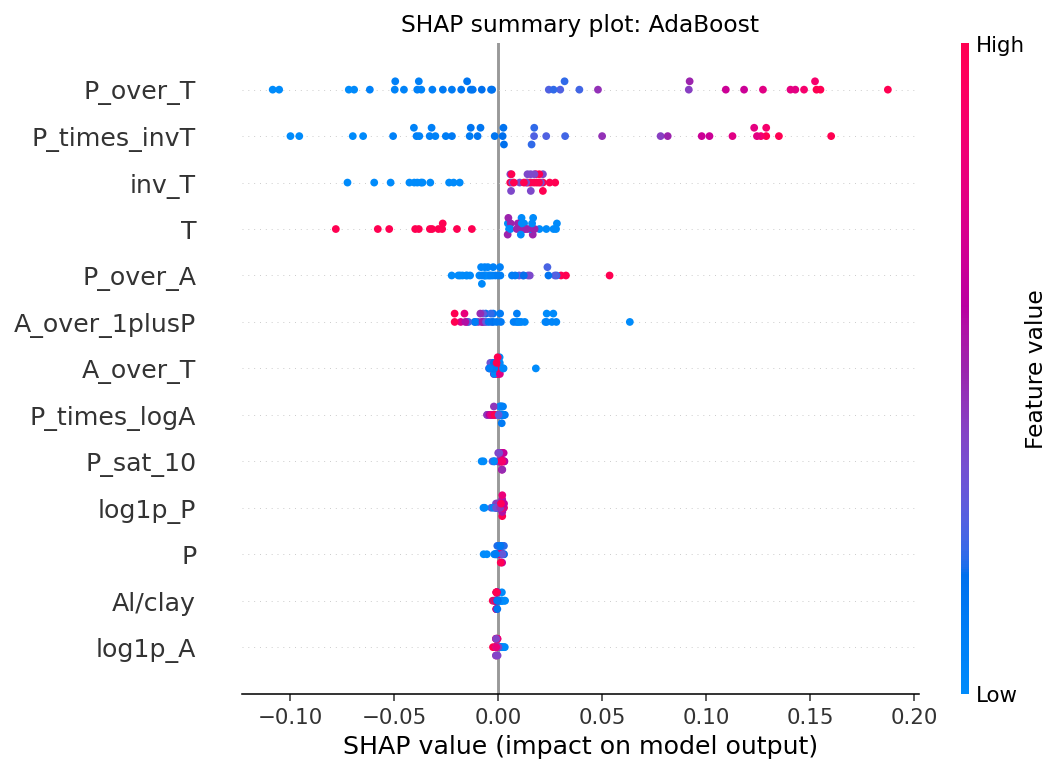

Saved: figures_PI_HySPAC\shap_summary_GBM.png
Saved: figures_PI_HySPAC\shap_summary_GBM.pdf


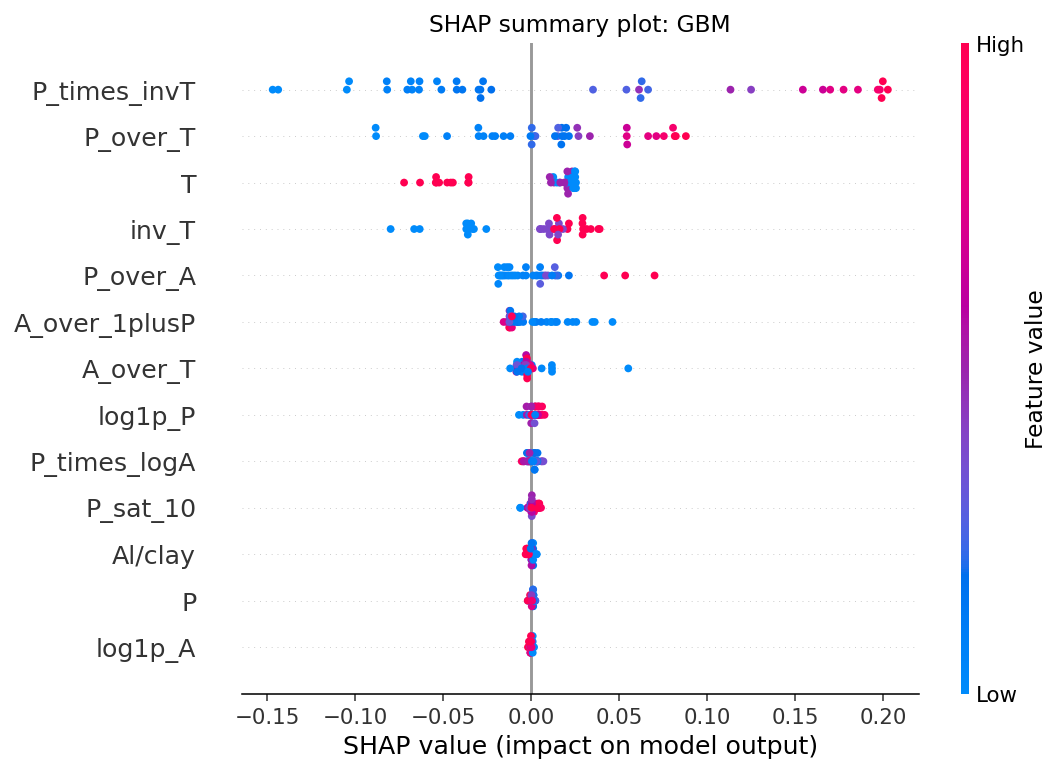

Saved: figures_PI_HySPAC\shap_summary_CatBoost.png
Saved: figures_PI_HySPAC\shap_summary_CatBoost.pdf


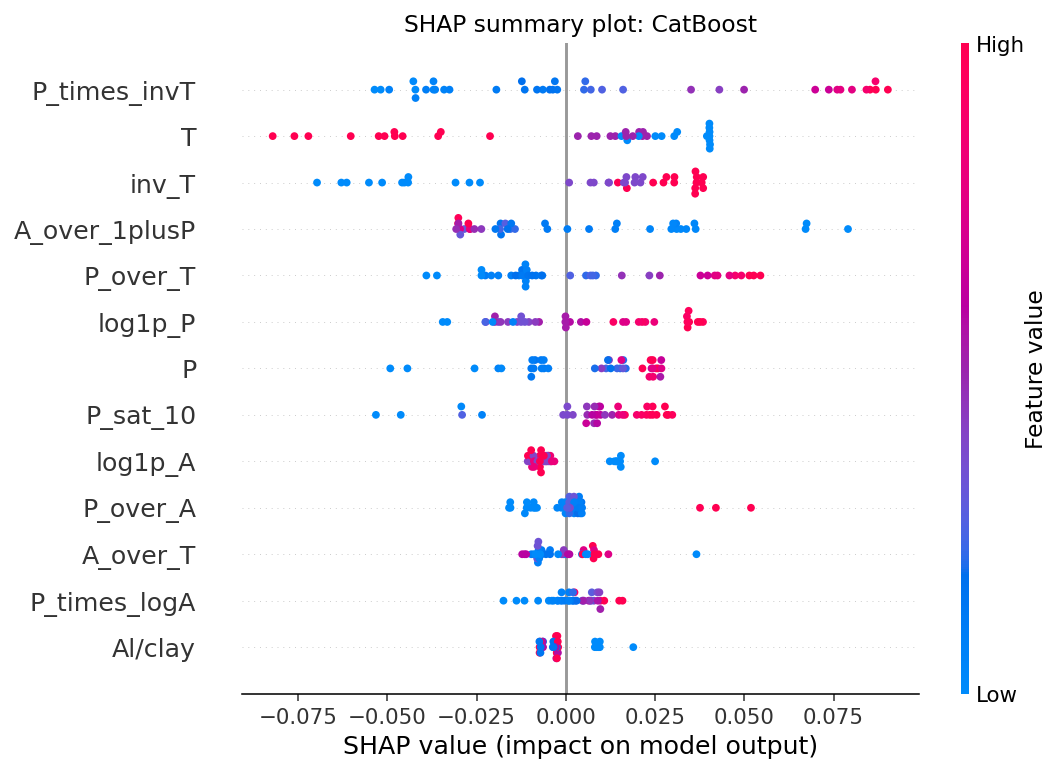

Saved: figures_PI_HySPAC\shap_summary_XGBoost.png
Saved: figures_PI_HySPAC\shap_summary_XGBoost.pdf


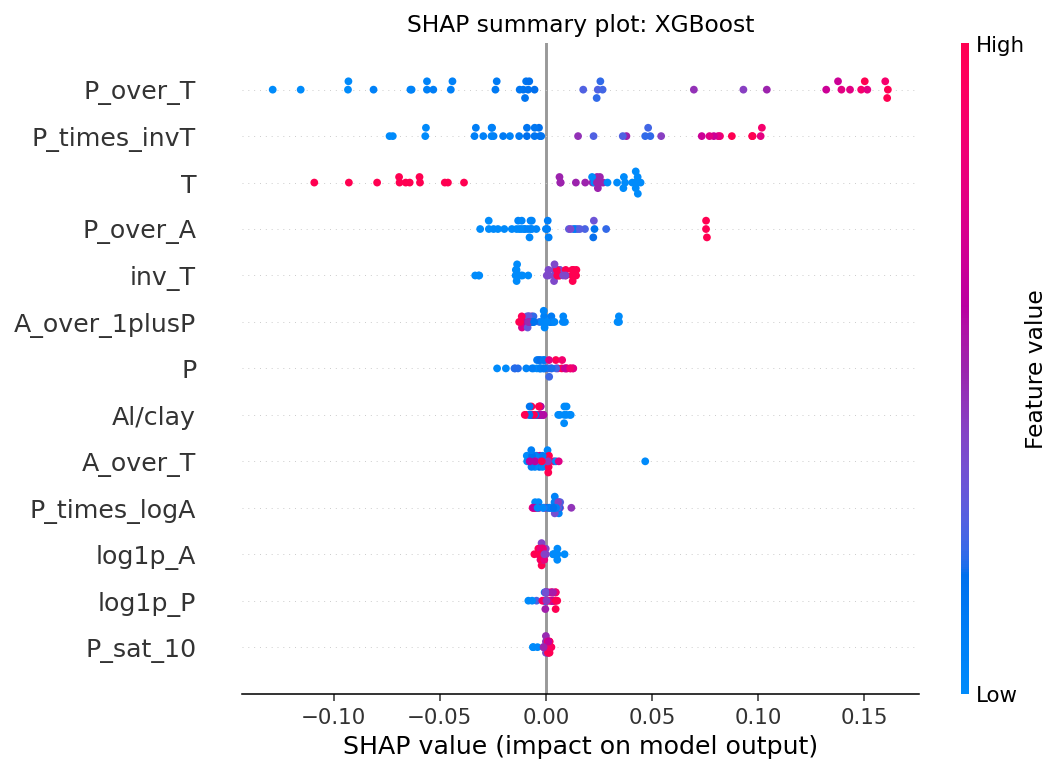

In [45]:
for model_name in baseline_models.keys():
    shap_vals = shap_results[model_name]["shap_values"]

    plt.figure(figsize=(8, 5.5))
    shap.summary_plot(
        shap_vals,
        X_shap_explain,
        show=False,
        plot_size=None
    )
    plt.title(f"SHAP summary plot: {model_name}")
    save_current_figure(f"shap_summary_{model_name}")
    plt.show()

# Cell A8 — SHAP bar plots for each baseline

Saved: figures_PI_HySPAC\shap_bar_AdaBoost.png
Saved: figures_PI_HySPAC\shap_bar_AdaBoost.pdf


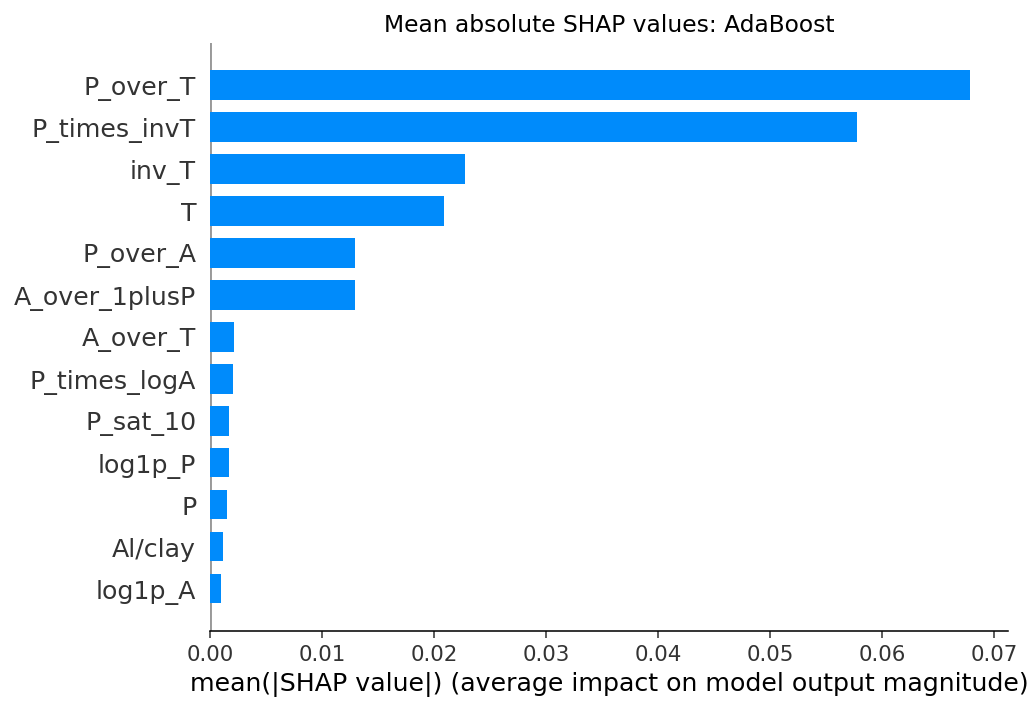

Saved: figures_PI_HySPAC\shap_bar_GBM.png
Saved: figures_PI_HySPAC\shap_bar_GBM.pdf


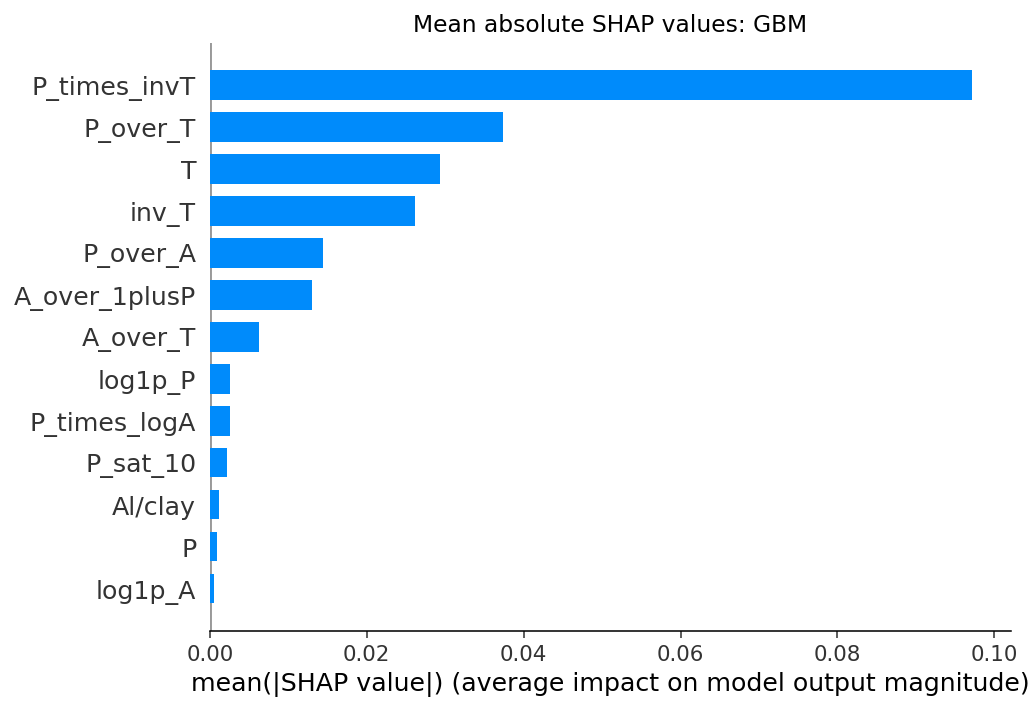

Saved: figures_PI_HySPAC\shap_bar_CatBoost.png
Saved: figures_PI_HySPAC\shap_bar_CatBoost.pdf


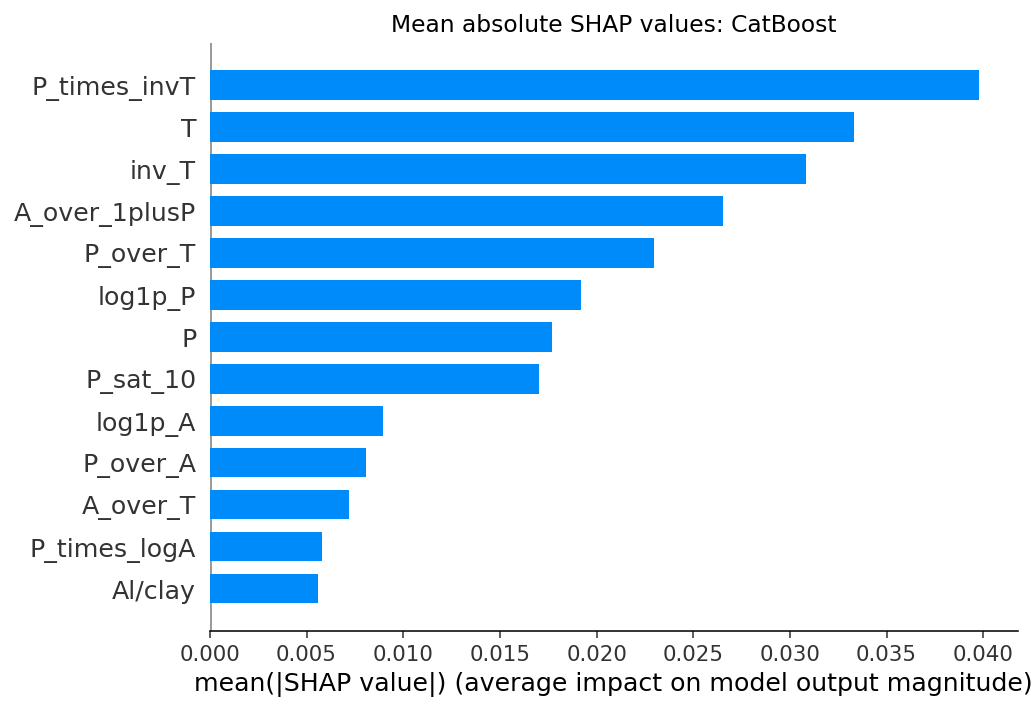

Saved: figures_PI_HySPAC\shap_bar_XGBoost.png
Saved: figures_PI_HySPAC\shap_bar_XGBoost.pdf


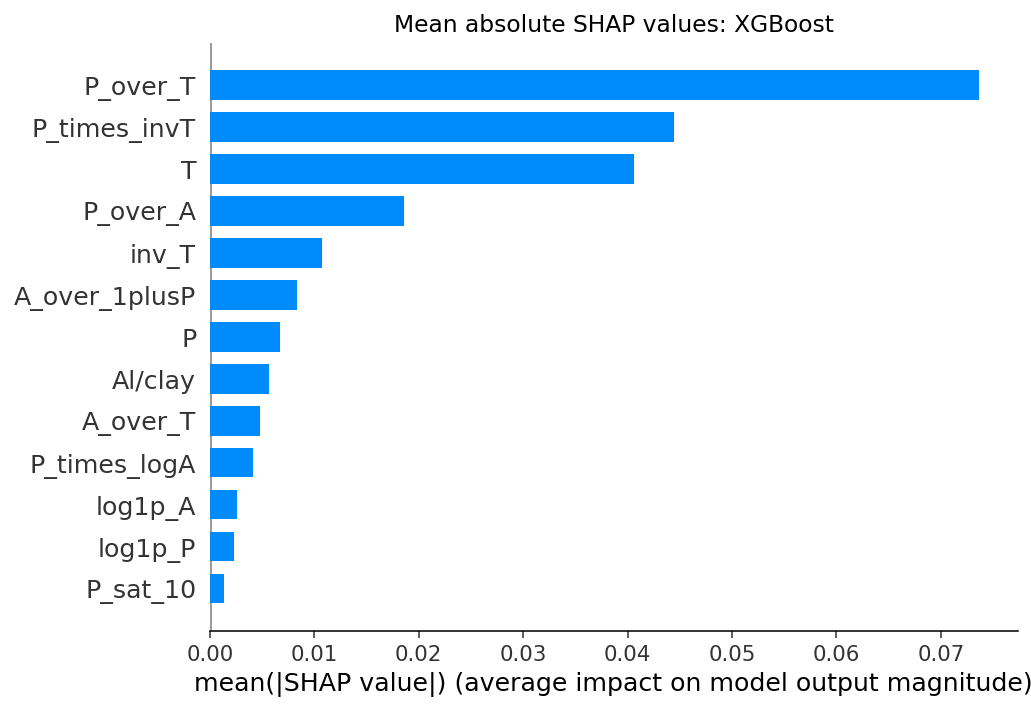

In [46]:
for model_name in baseline_models.keys():
    shap_vals = shap_results[model_name]["shap_values"]

    plt.figure(figsize=(7.5, 5.0))
    shap.summary_plot(
        shap_vals,
        X_shap_explain,
        plot_type="bar",
        show=False,
        plot_size=None
    )
    plt.title(f"Mean absolute SHAP values: {model_name}")
    save_current_figure(f"shap_bar_{model_name}")
    plt.show()

# Cell A9 — aggregated SHAP importance comparison figure

Saved: figures_PI_HySPAC\shap_top_features_all_baselines.png
Saved: figures_PI_HySPAC\shap_top_features_all_baselines.pdf


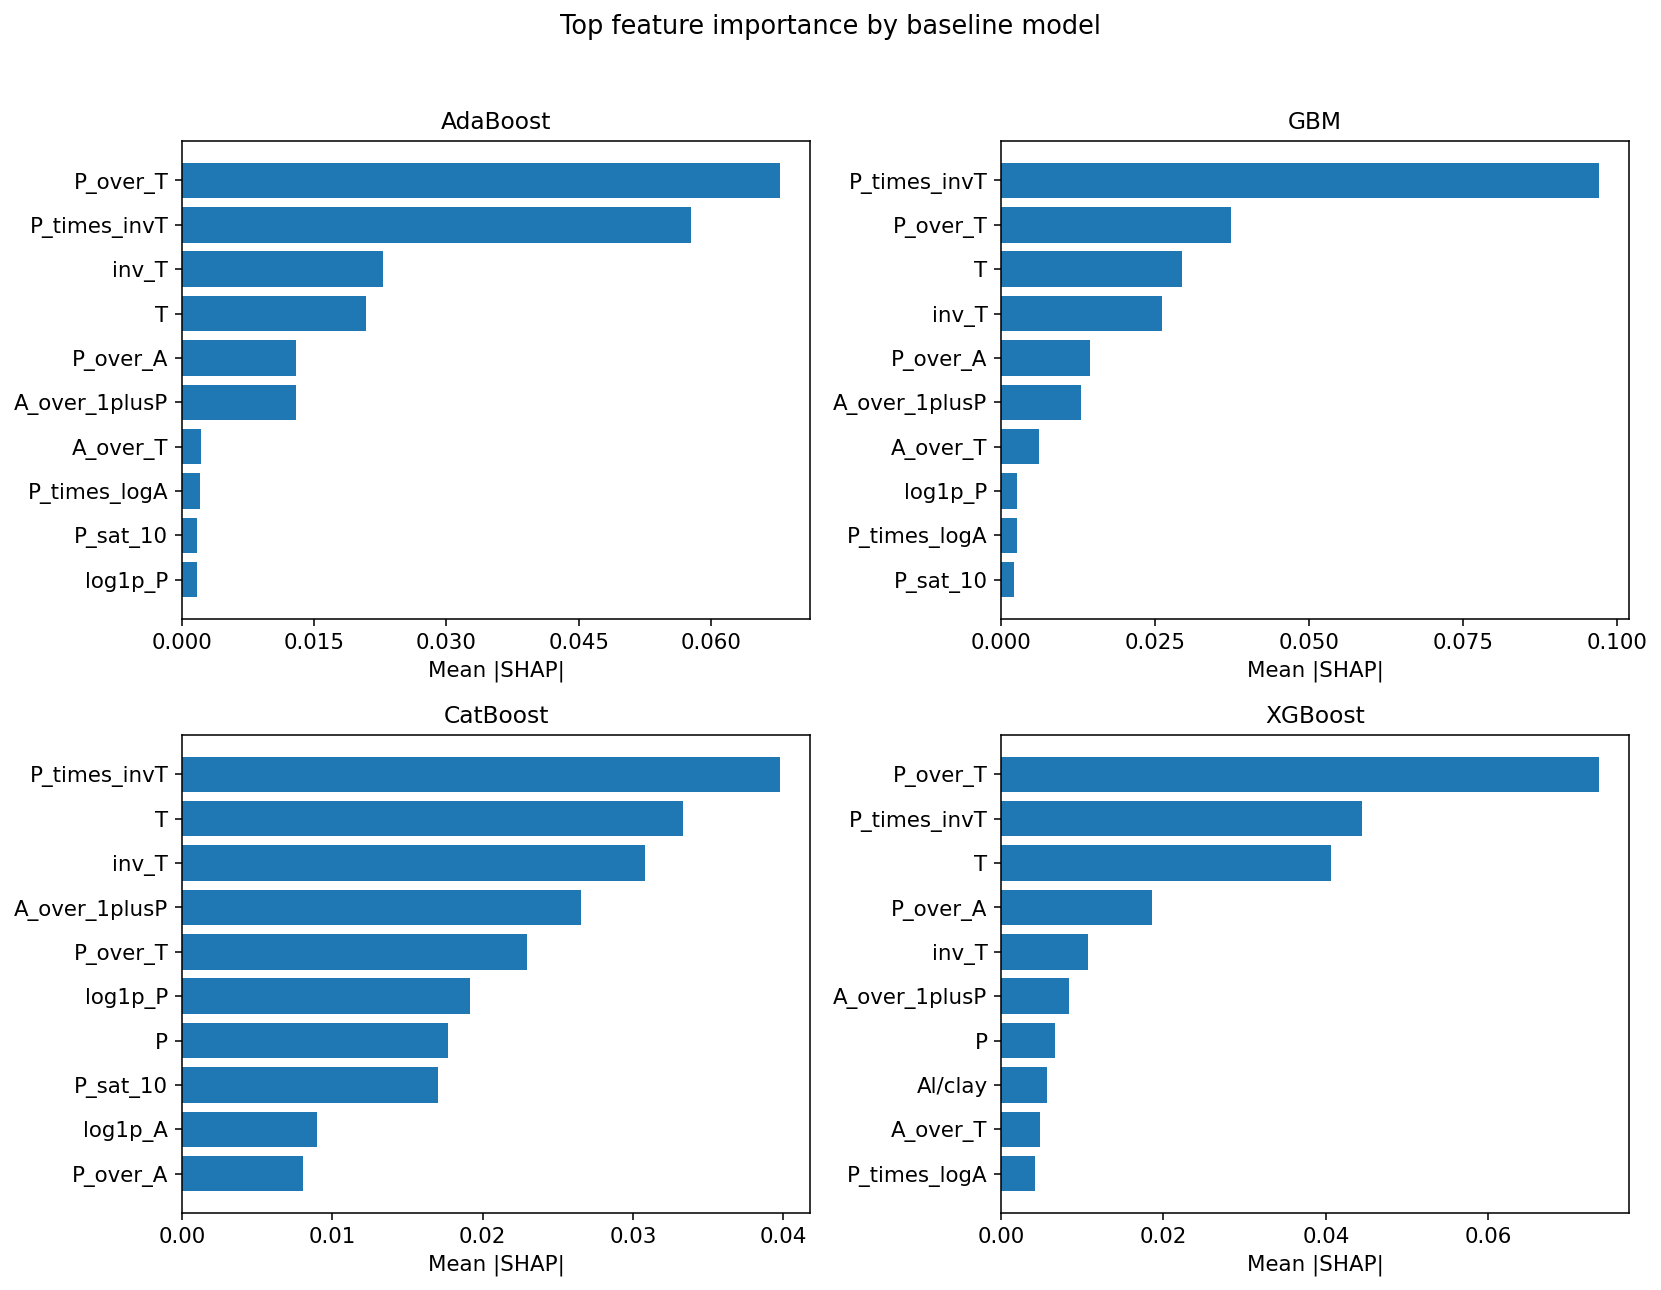

In [47]:
top_n = 10
agg_plot_df = shap_importance_df.copy()
agg_plot_df = agg_plot_df.sort_values(["Model", "MeanAbsSHAP"], ascending=[True, False])
agg_plot_df = agg_plot_df.groupby("Model").head(top_n)

models_in_order = ["AdaBoost", "GBM", "CatBoost", "XGBoost"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, model_name in zip(axes, models_in_order):
    sub = agg_plot_df[agg_plot_df["Model"] == model_name].sort_values("MeanAbsSHAP", ascending=True)
    ax.barh(sub["Feature"], sub["MeanAbsSHAP"])
    ax.set_title(model_name)
    ax.set_xlabel("Mean |SHAP|")
    ax.xaxis.set_major_locator(MaxNLocator(5))

plt.suptitle("Top feature importance by baseline model", y=1.02)
plt.tight_layout()
save_current_figure("shap_top_features_all_baselines")
plt.show()

# Cell A10 — PINN prediction wrapper for numpy input

In [49]:
def pinn_predict_from_dataframe(model, X_df, scaler_X, scaler_y):
    X_np = X_df.values.astype(np.float32)
    X_scaled = scaler_X.transform(X_np)
    y_pred = predict_pinn(model, X_scaled, scaler_y)
    return y_pred

# Cell A11 — PINN one-way sensitivity helper

In [50]:
def one_way_sensitivity(
    model,
    scaler_X,
    scaler_y,
    base_row_df,
    varying_col,
    grid_values,
    feature_cols_order
):
    """
    Varies one raw input while keeping all others fixed at a reference row.
    Recomputes physics-derived features consistently.
    """
    preds = []
    rows = []

    for v in grid_values:
        row = base_row_df.copy()
        row[varying_col] = v

        # rebuild engineered features from raw columns
        row_df = pd.DataFrame([row])
        row_df_feat = make_physics_features(row_df, PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL)
        X_row = row_df_feat[feature_cols_order]

        pred = pinn_predict_from_dataframe(model, X_row, scaler_X, scaler_y)[0]
        preds.append(pred)
        rows.append(X_row.iloc[0].to_dict())

    return np.array(grid_values), np.array(preds)

# Cell A12 — choose a reference point for sensitivity plots

In [52]:
# Use median operating point from the full dataset as reference
ref_raw = df[[PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL] + OPTIONAL_RAW_FEATURES].median(numeric_only=True)

# If there are non-numeric optional columns, this keeps only the numeric subset.
# Make sure required raw variables are present.
ref_dict = ref_raw.to_dict()

# Fill any optional raw features not covered above using first row fallback
for c in [PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL] + OPTIONAL_RAW_FEATURES:
    if c not in ref_dict:
        ref_dict[c] = df[c].iloc[0]

reference_row = pd.Series(ref_dict)
reference_row

P           12.977279
T          623.000000
Al/clay     30.000000
dtype: float64

# Cell A13 — PINN sensitivity: pressure

Saved: figures_PI_HySPAC\pinn_sensitivity_pressure.png
Saved: figures_PI_HySPAC\pinn_sensitivity_pressure.pdf


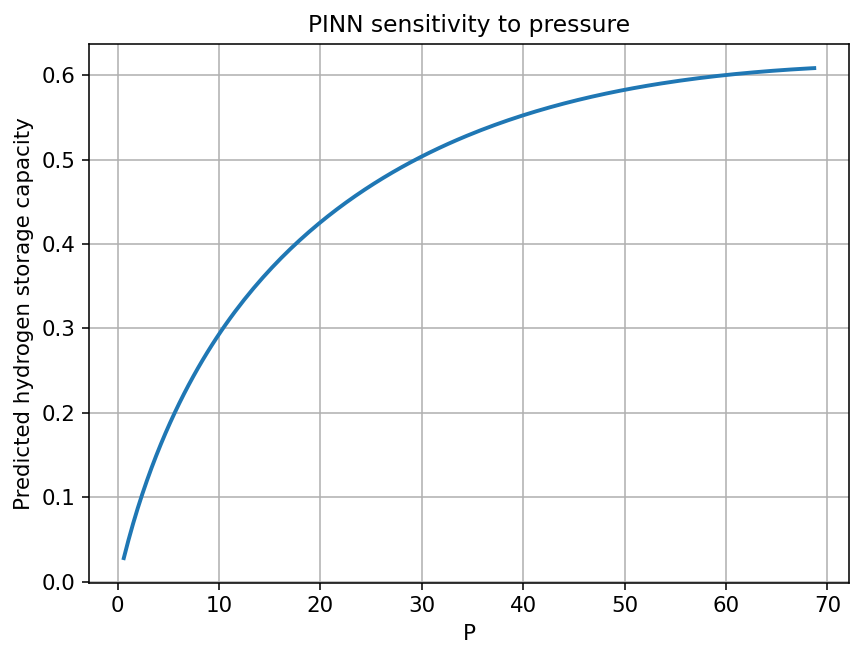

In [53]:
P_grid = np.linspace(df[PRESSURE_COL].min(), df[PRESSURE_COL].max(), 150)

xvals, yvals = one_way_sensitivity(
    model=final_pinn,
    scaler_X=scaler_X_pinn,
    scaler_y=scaler_y_pinn,
    base_row_df=reference_row,
    varying_col=PRESSURE_COL,
    grid_values=P_grid,
    feature_cols_order=feature_cols
)

plt.figure(figsize=(7, 5))
plt.plot(xvals, yvals, linewidth=2)
plt.xlabel(PRESSURE_COL)
plt.ylabel("Predicted hydrogen storage capacity")
plt.title("PINN sensitivity to pressure")
plt.grid(True)
save_current_figure("pinn_sensitivity_pressure")
plt.show()

# Cell A14 — PINN sensitivity: temperature

Saved: figures_PI_HySPAC\pinn_sensitivity_temperature.png
Saved: figures_PI_HySPAC\pinn_sensitivity_temperature.pdf


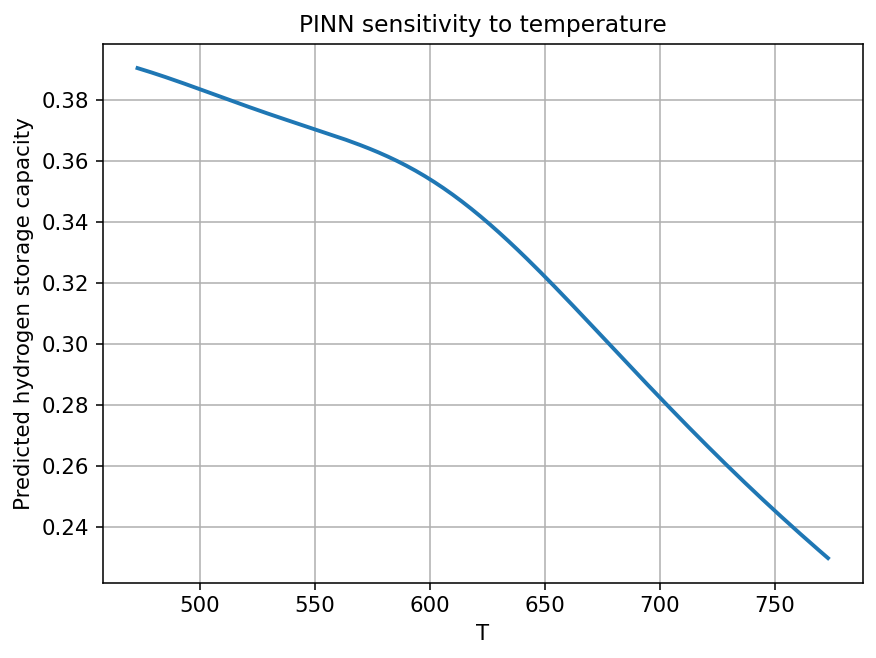

In [54]:
T_grid = np.linspace(df[TEMPERATURE_COL].min(), df[TEMPERATURE_COL].max(), 150)

xvals, yvals = one_way_sensitivity(
    model=final_pinn,
    scaler_X=scaler_X_pinn,
    scaler_y=scaler_y_pinn,
    base_row_df=reference_row,
    varying_col=TEMPERATURE_COL,
    grid_values=T_grid,
    feature_cols_order=feature_cols
)

plt.figure(figsize=(7, 5))
plt.plot(xvals, yvals, linewidth=2)
plt.xlabel(TEMPERATURE_COL)
plt.ylabel("Predicted hydrogen storage capacity")
plt.title("PINN sensitivity to temperature")
plt.grid(True)
save_current_figure("pinn_sensitivity_temperature")
plt.show()

# Cell A15 — PINN sensitivity: Al/clay

Saved: figures_PI_HySPAC\pinn_sensitivity_alclay.png
Saved: figures_PI_HySPAC\pinn_sensitivity_alclay.pdf


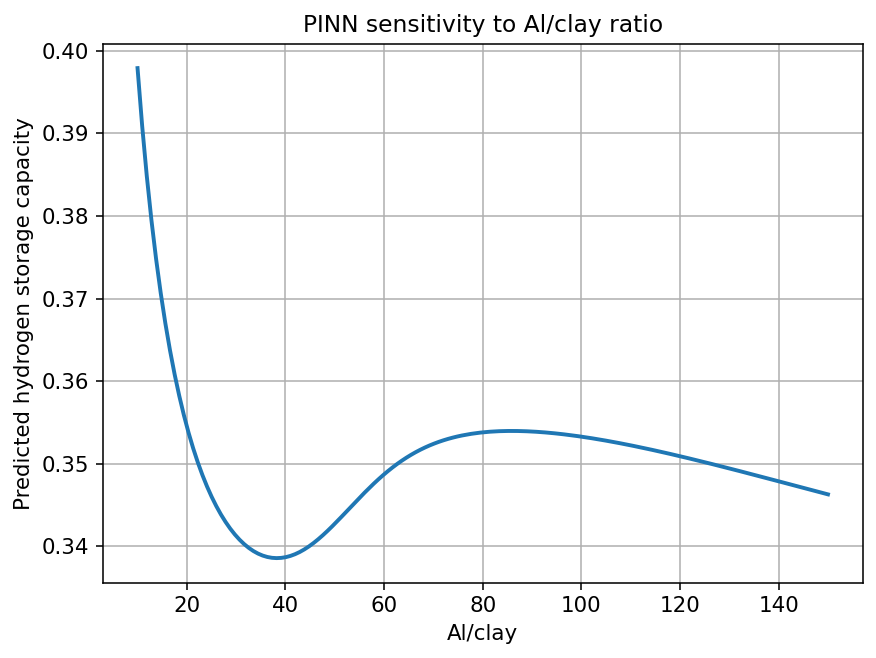

In [56]:
A_grid = np.linspace(df[ALCLAY_COL].min(), df[ALCLAY_COL].max(), 150)

xvals, yvals = one_way_sensitivity(
    model=final_pinn,
    scaler_X=scaler_X_pinn,
    scaler_y=scaler_y_pinn,
    base_row_df=reference_row,
    varying_col=ALCLAY_COL,
    grid_values=A_grid,
    feature_cols_order=feature_cols
)

plt.figure(figsize=(7, 5))
plt.plot(xvals, yvals, linewidth=2)
plt.xlabel(ALCLAY_COL)
plt.ylabel("Predicted hydrogen storage capacity")
plt.title("PINN sensitivity to Al/clay ratio")
plt.grid(True)
save_current_figure("pinn_sensitivity_alclay")
plt.show()

# Cell A16 — 2D PINN response surface: pressure vs temperature

Saved: figures_PI_HySPAC\pinn_surface_pressure_temperature.png
Saved: figures_PI_HySPAC\pinn_surface_pressure_temperature.pdf


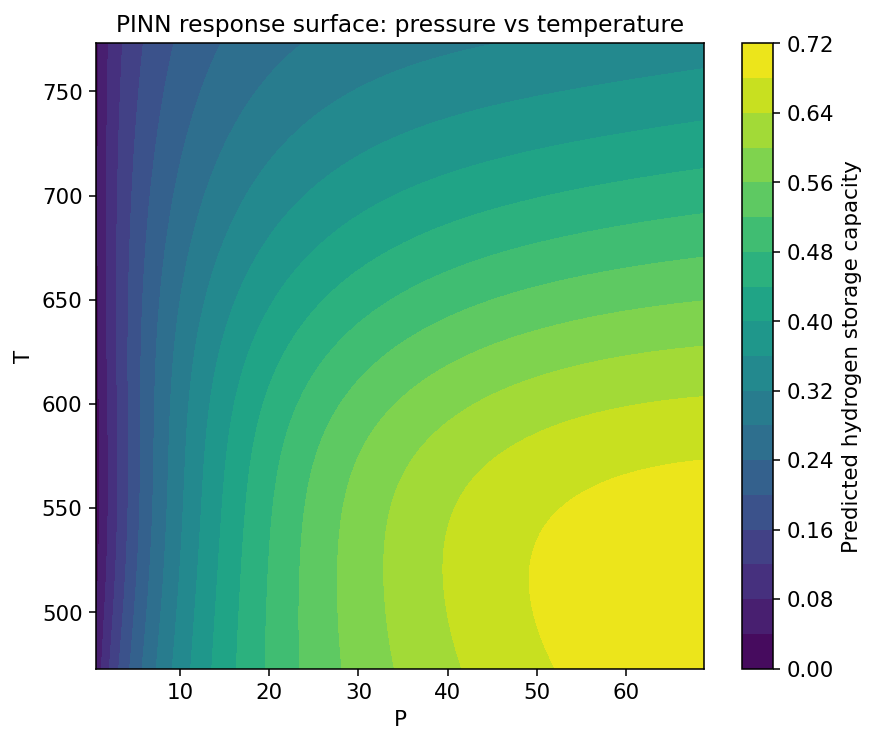

In [57]:
def two_way_surface(
    model,
    scaler_X,
    scaler_y,
    base_row_df,
    col_x,
    col_y,
    grid_x,
    grid_y,
    feature_cols_order
):
    Z = np.zeros((len(grid_y), len(grid_x)))
    for i, gy in enumerate(grid_y):
        for j, gx in enumerate(grid_x):
            row = base_row_df.copy()
            row[col_x] = gx
            row[col_y] = gy
            row_df = pd.DataFrame([row])
            row_df_feat = make_physics_features(row_df, PRESSURE_COL, TEMPERATURE_COL, ALCLAY_COL)
            X_row = row_df_feat[feature_cols_order]
            pred = pinn_predict_from_dataframe(model, X_row, scaler_X, scaler_y)[0]
            Z[i, j] = pred
    return Z

P_grid2 = np.linspace(df[PRESSURE_COL].min(), df[PRESSURE_COL].max(), 80)
T_grid2 = np.linspace(df[TEMPERATURE_COL].min(), df[TEMPERATURE_COL].max(), 80)

Z_PT = two_way_surface(
    model=final_pinn,
    scaler_X=scaler_X_pinn,
    scaler_y=scaler_y_pinn,
    base_row_df=reference_row,
    col_x=PRESSURE_COL,
    col_y=TEMPERATURE_COL,
    grid_x=P_grid2,
    grid_y=T_grid2,
    feature_cols_order=feature_cols
)

plt.figure(figsize=(7, 5.8))
cont = plt.contourf(P_grid2, T_grid2, Z_PT, levels=20)
plt.xlabel(PRESSURE_COL)
plt.ylabel(TEMPERATURE_COL)
plt.title("PINN response surface: pressure vs temperature")
plt.colorbar(cont, label="Predicted hydrogen storage capacity")
save_current_figure("pinn_surface_pressure_temperature")
plt.show()

# Cell A17 — manuscript-ready performance table

In [58]:
perf_iid = iid_results_df.copy()
perf_ood = ood_results_df.copy()

perf_table = pd.concat([perf_iid, perf_ood], axis=0).reset_index(drop=True)
perf_table = pretty_metric_table(perf_table)
save_dataframe_outputs(perf_table, "table_model_performance_iid_ood")
perf_table

Saved: tables_PI_HySPAC\table_model_performance_iid_ood.csv
Saved: tables_PI_HySPAC\table_model_performance_iid_ood.xlsx


,R2,RMSE,MAE,Model,Split
0,0.9943,0.0168,0.0133,PINN_PI-HySPAC,IID
1,0.9930,0.0186,0.0153,CatBoost,IID
2,0.9911,0.0211,0.0166,GBM,IID
3,0.9849,0.0275,0.0222,XGBoost,IID
4,0.9782,0.0330,0.0225,AdaBoost,IID
5,0.9853,0.0244,0.0197,AdaBoost,OOD_alclay_max_group
6,0.9794,0.0289,0.0220,GBM,OOD_alclay_max_group
7,0.9703,0.0346,0.0271,CatBoost,OOD_alclay_max_group
8,0.9700,0.0348,0.0265,XGBoost,OOD_alclay_max_group
9,0.8527,0.0771,0.0655,PINN_PI-HySPAC,OOD_alclay_max_group


# Cell A18 — manuscript-ready conformal table

In [59]:
conf_table = pretty_metric_table(conformal_results_df.copy())
save_dataframe_outputs(conf_table, "table_conformal_prediction_results")
conf_table

Saved: tables_PI_HySPAC\table_conformal_prediction_results.csv
Saved: tables_PI_HySPAC\table_conformal_prediction_results.xlsx


,Coverage,AvgWidth,ResidualQ90,Model,Split
4,0.8205,0.0294,0.0147,PINN_PI-HySPAC,IID
2,0.7692,0.0475,0.0237,CatBoost,IID
1,0.8974,0.0898,0.0449,GBM,IID
3,0.9487,0.1185,0.0593,XGBoost,IID
0,0.9487,0.1198,0.0599,AdaBoost,IID


# Cell A19 — manuscript-ready top SHAP summary table

In [60]:
top_shap_table = (
    shap_importance_df
    .sort_values(["Model", "MeanAbsSHAP"], ascending=[True, False])
    .groupby("Model")
    .head(5)
    .reset_index(drop=True)
)

top_shap_table["MeanAbsSHAP"] = top_shap_table["MeanAbsSHAP"].round(5)
save_dataframe_outputs(top_shap_table, "table_top5_shap_features_by_model")
top_shap_table

Saved: tables_PI_HySPAC\table_top5_shap_features_by_model.csv
Saved: tables_PI_HySPAC\table_top5_shap_features_by_model.xlsx


,Model,Feature,MeanAbsSHAP
0,AdaBoost,P_over_T,0.06785
1,AdaBoost,P_times_invT,0.05771
2,AdaBoost,inv_T,0.02277
3,AdaBoost,T,0.02092
4,AdaBoost,P_over_A,0.01294
5,CatBoost,P_times_invT,0.03980
6,CatBoost,T,0.03333
7,CatBoost,inv_T,0.03083
8,CatBoost,A_over_1plusP,0.02656
9,CatBoost,P_over_T,0.02298


# Cell A20 — manuscript-ready parity plot for IID

Saved: figures_PI_HySPAC\parity_iid_all_models.png
Saved: figures_PI_HySPAC\parity_iid_all_models.pdf


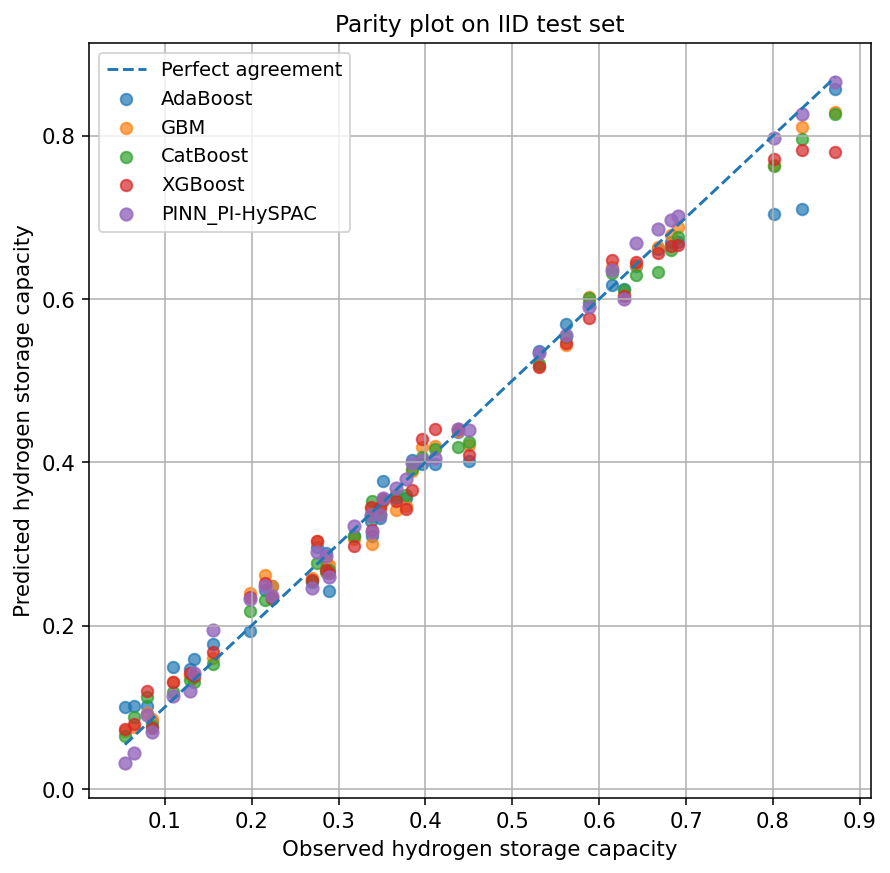

In [61]:
plt.figure(figsize=(7.2, 7.0))

# perfect line
all_obs = y_test_iid
mn, mx = np.min(all_obs), np.max(all_obs)
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5, label="Perfect agreement")

for model_name, model in baseline_models.items():
    pred = model.predict(X_test_iid)
    plt.scatter(y_test_iid, pred, s=35, alpha=0.70, label=model_name)

plt.scatter(y_test_iid, pred_pinn_iid, s=40, alpha=0.80, label="PINN_PI-HySPAC")

plt.xlabel("Observed hydrogen storage capacity")
plt.ylabel("Predicted hydrogen storage capacity")
plt.title("Parity plot on IID test set")
plt.legend()
plt.grid(True)
save_current_figure("parity_iid_all_models")
plt.show()

Saved: figures_PI_HySPAC\parity_iid_grid_2x3_models.png
Saved: figures_PI_HySPAC\parity_iid_grid_2x3_models.pdf


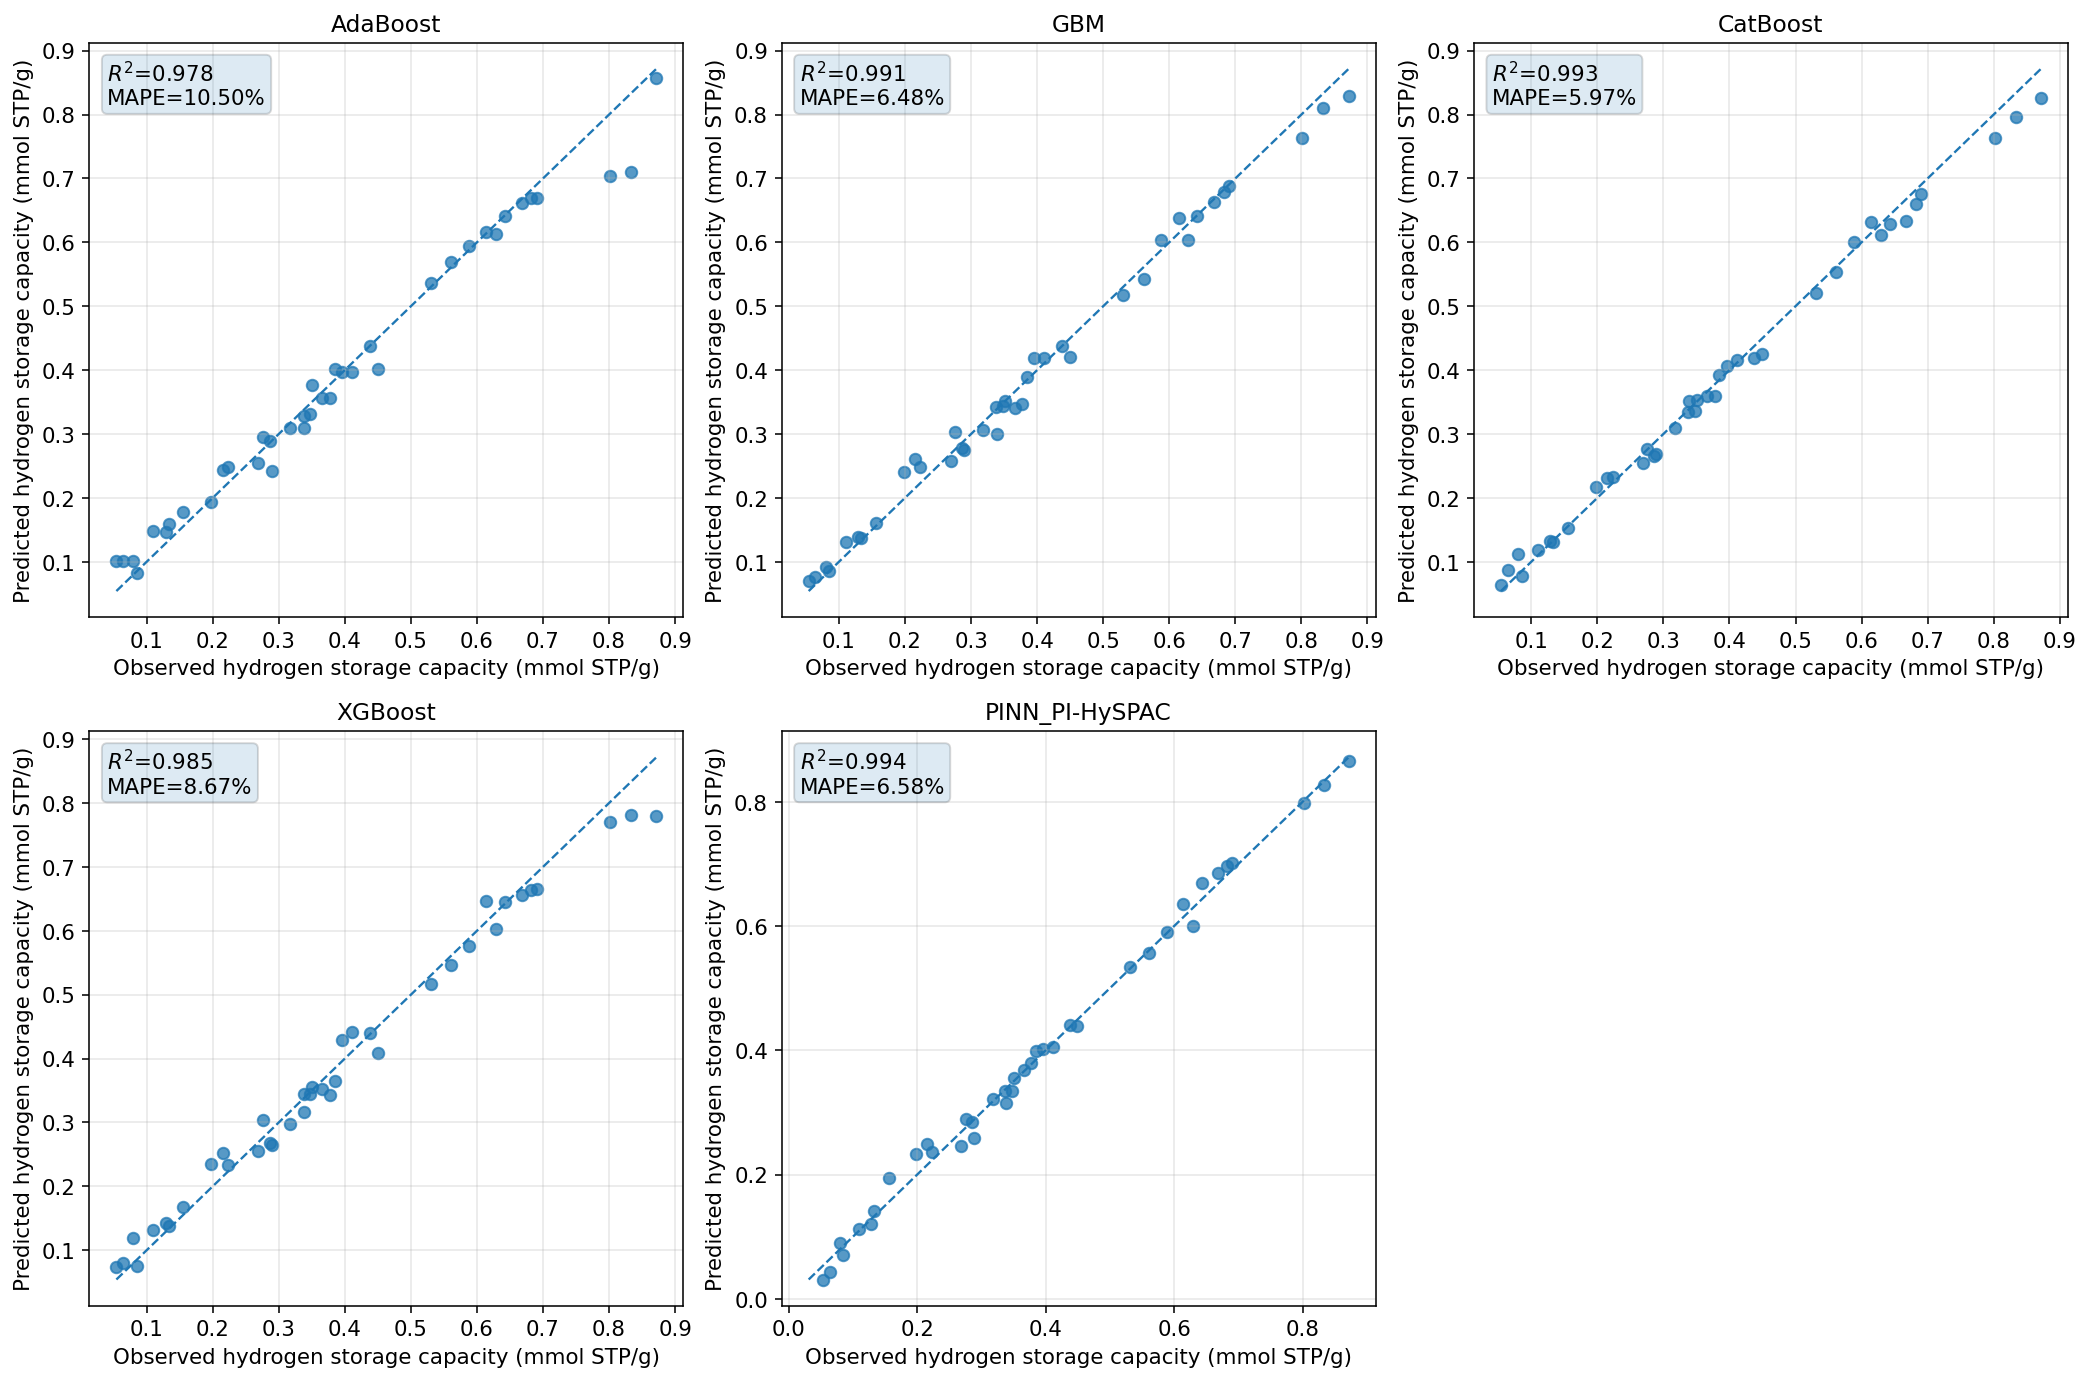

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

model_predictions = {}

for model_name, model in baseline_models.items():
    model_predictions[model_name] = model.predict(X_test_iid)

model_predictions["PINN_PI-HySPAC"] = pred_pinn_iid

panel_names = ["AdaBoost", "GBM", "CatBoost", "XGBoost", "PINN_PI-HySPAC"]

for i, model_name in enumerate(panel_names):
    ax = axes[i]

    y_true = y_test_iid
    y_pred = model_predictions[model_name]

    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))

    ax.scatter(y_true, y_pred, s=35, alpha=0.75)
    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.2)

    met = regression_metrics_extended(y_true, y_pred)

    ax.set_title(model_name)
    ax.set_xlabel("Observed hydrogen storage capacity (mmol STP/g)")
    ax.set_ylabel("Predicted hydrogen storage capacity (mmol STP/g)")
    ax.text(
        0.03, 0.97,
        f"$R^2$={met['R2']:.3f}\nMAPE={met['MAPE']:.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    ax.grid(True, alpha=0.3)

# delete the unused 6th panel
for j in range(len(panel_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_current_figure("parity_iid_grid_2x3_models")
plt.show()

Saved: figures_PI_HySPAC\iid_rmse_comparison.png
Saved: figures_PI_HySPAC\iid_rmse_comparison.pdf


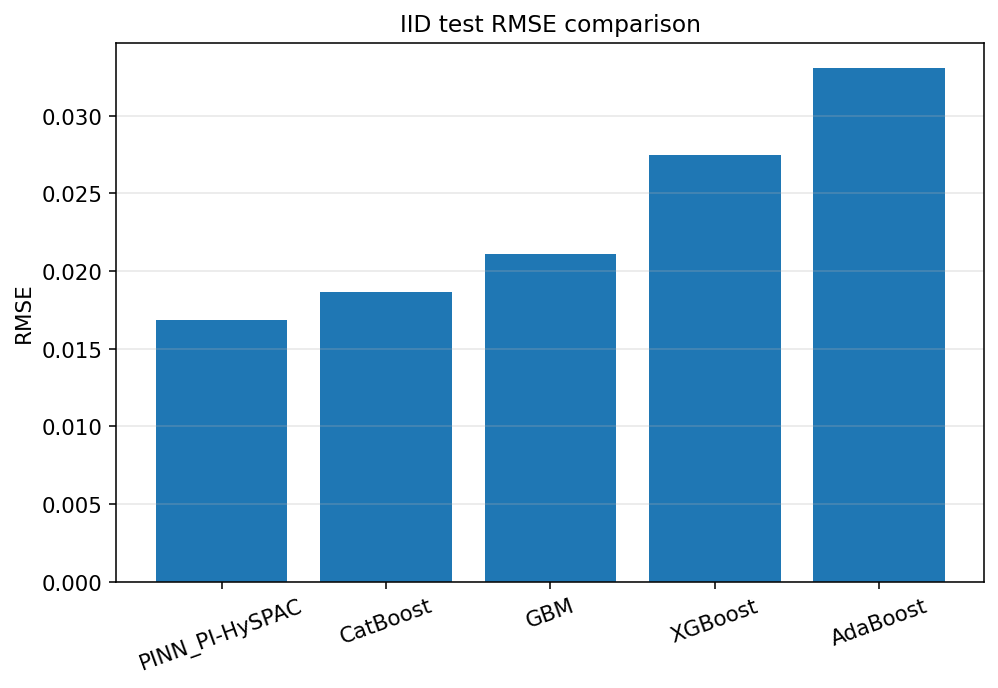

Saved: figures_PI_HySPAC\iid_r2_comparison.png
Saved: figures_PI_HySPAC\iid_r2_comparison.pdf


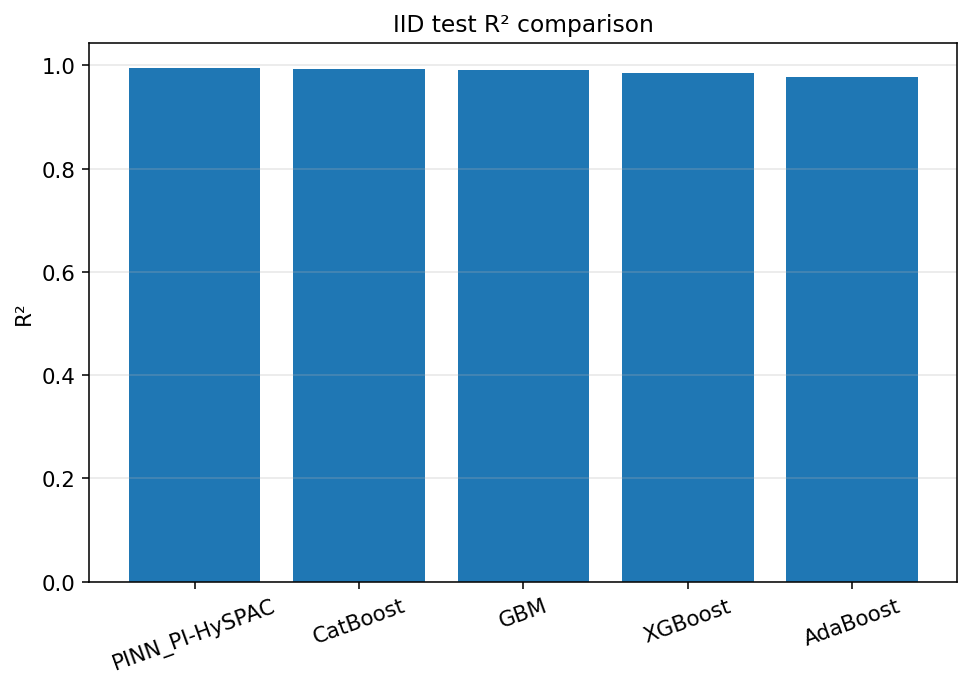

In [62]:
plot_df = iid_results_df.copy().sort_values("RMSE")
x = np.arange(len(plot_df))

plt.figure(figsize=(8, 5))
plt.bar(x, plot_df["RMSE"])
plt.xticks(x, plot_df["Model"], rotation=20)
plt.ylabel("RMSE")
plt.title("IID test RMSE comparison")
plt.grid(True, axis="y", alpha=0.3)
save_current_figure("iid_rmse_comparison")
plt.show()

plt.figure(figsize=(8, 5))
plot_df_r2 = iid_results_df.copy().sort_values("R2", ascending=False)
x = np.arange(len(plot_df_r2))
plt.bar(x, plot_df_r2["R2"])
plt.xticks(x, plot_df_r2["Model"], rotation=20)
plt.ylabel("R²")
plt.title("IID test R² comparison")
plt.grid(True, axis="y", alpha=0.3)
save_current_figure("iid_r2_comparison")
plt.show()

Saved: figures_PI_HySPAC\ood_rmse_by_split.png
Saved: figures_PI_HySPAC\ood_rmse_by_split.pdf


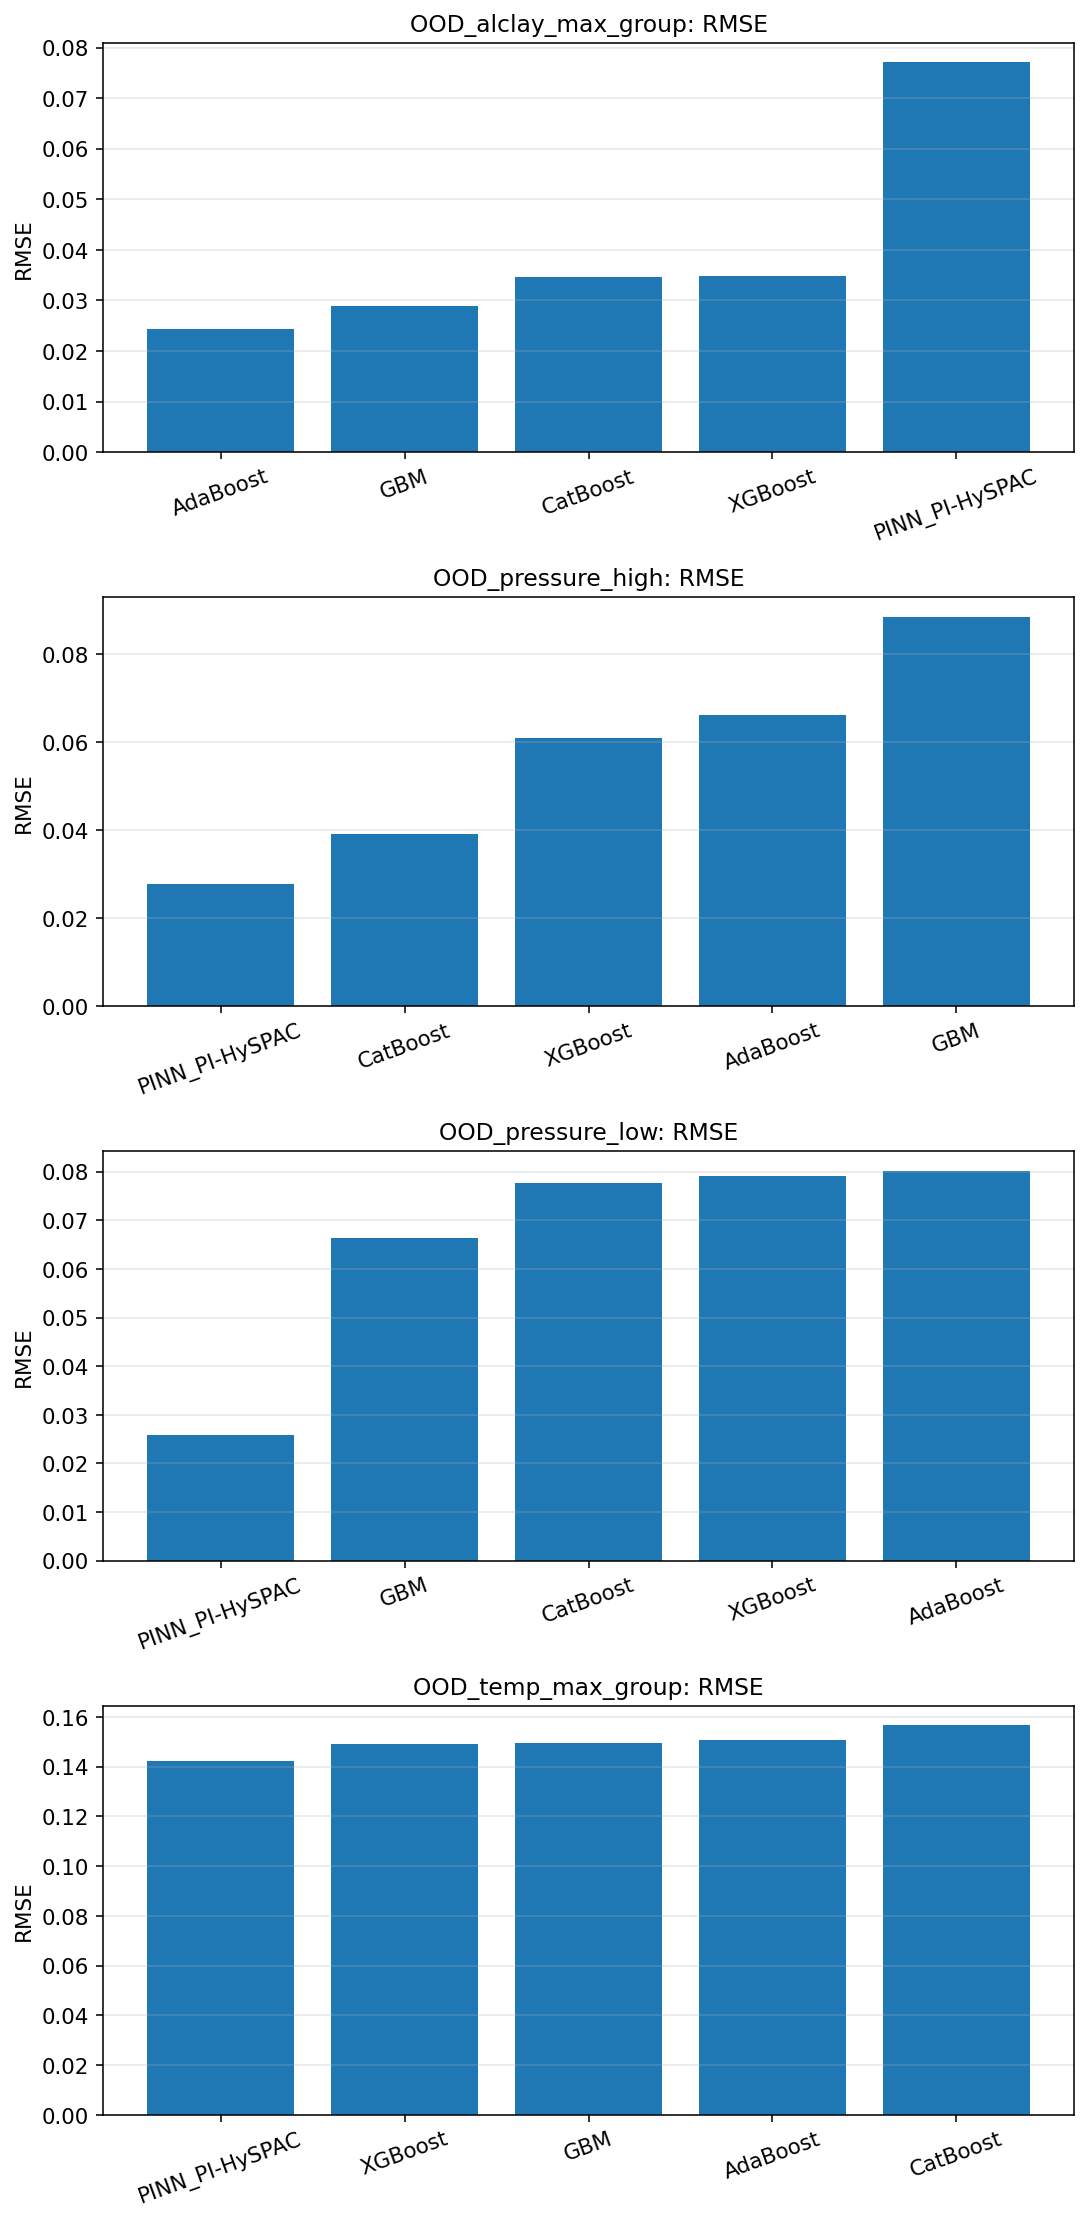

In [63]:
ood_plot_df = ood_results_df.copy()

splits = ood_plot_df["Split"].unique()
fig, axes = plt.subplots(len(splits), 1, figsize=(8, 4 * len(splits)))

if len(splits) == 1:
    axes = [axes]

for ax, split_name in zip(axes, splits):
    sub = ood_plot_df[ood_plot_df["Split"] == split_name].sort_values("RMSE")
    ax.bar(sub["Model"], sub["RMSE"])
    ax.set_title(f"{split_name}: RMSE")
    ax.set_ylabel("RMSE")
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
save_current_figure("ood_rmse_by_split")
plt.show()

In [64]:
captions = {
    "shap_top_features_all_baselines":
        "Comparison of the top-ranked input features across the four ensemble baseline models using mean absolute SHAP values. Pressure- and temperature-related variables are expected to dominate if the learned behavior remains physically consistent.",
    "pinn_sensitivity_pressure":
        "One-way sensitivity of the PI-HySPAC model to pressure, obtained by varying pressure while holding the remaining inputs at a reference operating point.",
    "pinn_sensitivity_temperature":
        "One-way sensitivity of the PI-HySPAC model to temperature, obtained by varying temperature while holding the remaining inputs at a reference operating point.",
    "pinn_sensitivity_alclay":
        "One-way sensitivity of the PI-HySPAC model to alumina/clay ratio, obtained by varying composition while holding the remaining inputs at a reference operating point.",
    "pinn_surface_pressure_temperature":
        "Two-dimensional response surface predicted by the PI-HySPAC model as a function of pressure and temperature, with remaining inputs fixed at a reference point.",
    "parity_iid_all_models":
        "Parity plot comparing observed and predicted hydrogen storage capacities on the IID test set for the four ensemble baselines and the proposed PI-HySPAC model.",
    "ood_rmse_by_split":
        "Comparison of model RMSE values under multiple out-of-distribution evaluation settings, including tail and group-based holdout tests.",
}

caption_df = pd.DataFrame({
    "FigureName": list(captions.keys()),
    "Caption": list(captions.values())
})
save_dataframe_outputs(caption_df, "figure_captions_draft")
caption_df

Saved: tables_PI_HySPAC\figure_captions_draft.csv
Saved: tables_PI_HySPAC\figure_captions_draft.xlsx


,FigureName,Caption
0,shap_top_features_all_baselines,Comparison of the top-ranked input features ac...
1,pinn_sensitivity_pressure,One-way sensitivity of the PI-HySPAC model to ...
2,pinn_sensitivity_temperature,One-way sensitivity of the PI-HySPAC model to ...
3,pinn_sensitivity_alclay,One-way sensitivity of the PI-HySPAC model to ...
4,pinn_surface_pressure_temperature,Two-dimensional response surface predicted by ...
5,parity_iid_all_models,Parity plot comparing observed and predicted h...
6,ood_rmse_by_split,Comparison of model RMSE values under multiple...


In [65]:
print("Created folders:")
print(" -", FIG_DIR)
print(" -", TAB_DIR)

print("\nMain exported items:")
print("Figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print(" ", f)

print("\nTables:")
for f in sorted(os.listdir(TAB_DIR)):
    print(" ", f)

Created folders:
 - figures_PI_HySPAC
 - tables_PI_HySPAC

Main exported items:
Figures:
  iid_r2_comparison.pdf
  iid_r2_comparison.png
  iid_rmse_comparison.pdf
  iid_rmse_comparison.png
  ood_rmse_by_split.pdf
  ood_rmse_by_split.png
  parity_iid_all_models.pdf
  parity_iid_all_models.png
  pinn_sensitivity_alclay.pdf
  pinn_sensitivity_alclay.png
  pinn_sensitivity_pressure.pdf
  pinn_sensitivity_pressure.png
  pinn_sensitivity_temperature.pdf
  pinn_sensitivity_temperature.png
  pinn_surface_pressure_temperature.pdf
  pinn_surface_pressure_temperature.png
  shap_bar_AdaBoost.pdf
  shap_bar_AdaBoost.png
  shap_bar_CatBoost.pdf
  shap_bar_CatBoost.png
  shap_bar_GBM.pdf
  shap_bar_GBM.png
  shap_bar_XGBoost.pdf
  shap_bar_XGBoost.png
  shap_summary_AdaBoost.pdf
  shap_summary_AdaBoost.png
  shap_summary_CatBoost.pdf
  shap_summary_CatBoost.png
  shap_summary_GBM.pdf
  shap_summary_GBM.png
  shap_summary_XGBoost.pdf
  shap_summary_XGBoost.png
  shap_top_features_all_baselines.pdf
  s

In [67]:
def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0


def regression_metrics_extended(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }

In [68]:
N_REPEATS = 30

def repeated_iid_evaluation(df_feat, n_repeats=30, test_size=0.20):
    rows = []

    for rep in range(n_repeats):
        seed = RANDOM_STATE + rep

        X_all_local = df_feat[feature_cols].copy()
        y_all_local = df_feat[TARGET_COL].values

        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X_all_local, y_all_local, test_size=test_size, random_state=seed
        )

        X_train, X_cal, y_train, y_cal = train_test_split(
            X_train_full, y_train_full, test_size=CAL_SIZE_FROM_TRAIN, random_state=seed
        )

        # Baselines
        for model_name, builder in {
            "AdaBoost": build_adaboost,
            "GBM": build_gbm,
            "CatBoost": build_catboost,
            "XGBoost": build_xgboost
        }.items():
            model = builder(baseline_best_params[model_name])
            model.fit(pd.concat([X_train, X_cal], axis=0), np.concatenate([y_train, y_cal]))
            pred = model.predict(X_test)
            met = regression_metrics_extended(y_test, pred)
            met["Model"] = model_name
            met["Split"] = "IID"
            met["Repeat"] = rep
            rows.append(met)

        # PINN
        X_traincal = pd.concat([X_train, X_cal], axis=0)
        y_traincal = np.concatenate([y_train, y_cal])

        scX = StandardScaler()
        scy = StandardScaler()

        X_traincal_np = X_traincal.values.astype(np.float32)
        y_traincal_np = y_traincal.reshape(-1, 1).astype(np.float32)
        X_test_np = X_test.values.astype(np.float32)

        X_traincal_scaled = scX.fit_transform(X_traincal_np)
        y_traincal_scaled = scy.fit_transform(y_traincal_np)
        X_test_scaled = scX.transform(X_test_np)

        X_subtr, X_subva, y_subtr, y_subva = train_test_split(
            X_traincal_scaled, y_traincal_scaled, test_size=0.15, random_state=seed
        )

        pinn_model, _, _ = train_pinn_once(
            X_subtr, y_subtr, X_subva, y_subva,
            params=best_pinn_params,
            verbose=False
        )

        pred = predict_pinn(pinn_model, X_test_scaled, scy)
        met = regression_metrics_extended(y_test, pred)
        met["Model"] = "PINN_PI-HySPAC"
        met["Split"] = "IID"
        met["Repeat"] = rep
        rows.append(met)

    return pd.DataFrame(rows)


iid_repeated_df = repeated_iid_evaluation(df_feat, n_repeats=N_REPEATS, test_size=TEST_SIZE)
iid_repeated_df.head()

,R2,RMSE,MAE,MAPE,Model,Split,Repeat
0,0.978163,0.033045,0.022467,10.495166,AdaBoost,IID,0
1,0.991074,0.021127,0.016618,6.479094,GBM,IID,0
2,0.993047,0.018647,0.015298,5.971706,CatBoost,IID,0
3,0.984905,0.027474,0.022153,8.670819,XGBoost,IID,0
4,0.994325,0.016846,0.013263,6.581673,PINN_PI-HySPAC,IID,0


In [69]:
def repeated_ood_evaluation(df_feat, n_repeats=30):
    rows = []

    for rep in range(n_repeats):
        seed = RANDOM_STATE + rep

        # Rebuild OOD splits each time from full data
        splits = make_ood_splits(df_feat)

        for split_name, (Xtr, ytr, Xte, yte) in splits.items():

            # Baselines
            for model_name, builder in {
                "AdaBoost": build_adaboost,
                "GBM": build_gbm,
                "CatBoost": build_catboost,
                "XGBoost": build_xgboost
            }.items():
                model = builder(baseline_best_params[model_name])
                model.fit(Xtr, ytr)
                pred = model.predict(Xte)

                met = regression_metrics_extended(yte, pred)
                met["Model"] = model_name
                met["Split"] = split_name
                met["Repeat"] = rep
                rows.append(met)

            # PINN
            scX = StandardScaler()
            scy = StandardScaler()

            Xtr_np = Xtr.values.astype(np.float32)
            Xte_np = Xte.values.astype(np.float32)
            ytr_np = ytr.reshape(-1, 1).astype(np.float32)

            Xtr_scaled = scX.fit_transform(Xtr_np)
            Xte_scaled = scX.transform(Xte_np)
            ytr_scaled = scy.fit_transform(ytr_np)

            X_subtr, X_subva, y_subtr, y_subva = train_test_split(
                Xtr_scaled, ytr_scaled, test_size=0.15, random_state=seed
            )

            pinn_model, _, _ = train_pinn_once(
                X_subtr, y_subtr, X_subva, y_subva,
                params=best_pinn_params,
                verbose=False
            )

            pred = predict_pinn(pinn_model, Xte_scaled, scy)

            met = regression_metrics_extended(yte, pred)
            met["Model"] = "PINN_PI-HySPAC"
            met["Split"] = split_name
            met["Repeat"] = rep
            rows.append(met)

    return pd.DataFrame(rows)


ood_repeated_df = repeated_ood_evaluation(df_feat, n_repeats=N_REPEATS)
ood_repeated_df.head()

,R2,RMSE,MAE,MAPE,Model,Split,Repeat
0,0.762340,0.066152,0.049412,8.756032,AdaBoost,OOD_pressure_high,0
1,0.574221,0.088544,0.078446,13.442106,GBM,OOD_pressure_high,0
2,0.917143,0.039060,0.034479,5.798114,CatBoost,OOD_pressure_high,0
3,0.797619,0.061045,0.047409,8.962802,XGBoost,OOD_pressure_high,0
4,0.958267,0.027721,0.022368,3.893618,PINN_PI-HySPAC,OOD_pressure_high,0


In [70]:
def summarize_with_ci(df_rep, metrics=("R2", "MAPE", "RMSE", "MAE")):
    rows = []

    for (split_name, model_name), sub in df_rep.groupby(["Split", "Model"]):
        row = {"Split": split_name, "Model": model_name, "n": len(sub)}

        for metric in metrics:
            vals = sub[metric].values.astype(float)
            mean_val = np.mean(vals)
            std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            se_val = std_val / np.sqrt(len(vals)) if len(vals) > 0 else 0.0
            ci95 = 1.96 * se_val

            row[f"{metric}_mean"] = mean_val
            row[f"{metric}_std"] = std_val
            row[f"{metric}_ci95"] = ci95

        rows.append(row)

    return pd.DataFrame(rows)


iid_ci_df = summarize_with_ci(iid_repeated_df)
ood_ci_df = summarize_with_ci(ood_repeated_df)

save_dataframe_outputs(pretty_metric_table(iid_ci_df), "iid_repeated_metrics_ci")
save_dataframe_outputs(pretty_metric_table(ood_ci_df), "ood_repeated_metrics_ci")

iid_ci_df.head(), ood_ci_df.head()

Saved: tables_PI_HySPAC\iid_repeated_metrics_ci.csv
Saved: tables_PI_HySPAC\iid_repeated_metrics_ci.xlsx
Saved: tables_PI_HySPAC\ood_repeated_metrics_ci.csv
Saved: tables_PI_HySPAC\ood_repeated_metrics_ci.xlsx


(  Split           Model   n   R2_mean    R2_std   R2_ci95  MAPE_mean  \
 0   IID        AdaBoost  30  0.961646  0.026442  0.009462  11.391398   
 1   IID        CatBoost  30  0.990524  0.003785  0.001354   6.641300   
 2   IID             GBM  30  0.980575  0.010431  0.003733   7.717955   
 3   IID  PINN_PI-HySPAC  30  0.994970  0.002478  0.000887   5.398502   
 4   IID         XGBoost  30  0.977711  0.011049  0.003954   8.932462   
 
    MAPE_std  MAPE_ci95  RMSE_mean  RMSE_std  RMSE_ci95  MAE_mean   MAE_std  \
 0  3.190285   1.141629   0.036849  0.010842   0.003880  0.024801  0.004982   
 1  2.417214   0.864989   0.019056  0.004319   0.001545  0.014277  0.002942   
 2  1.884481   0.674353   0.026692  0.006110   0.002187  0.019259  0.003008   
 3  2.267841   0.811536   0.013691  0.003621   0.001296  0.010090  0.002359   
 4  2.782304   0.995635   0.028836  0.007173   0.002567  0.020882  0.004691   
 
    MAE_ci95  
 0  0.001783  
 1  0.001053  
 2  0.001077  
 3  0.000844  
 4  0.001

In [71]:
# Choose 5 OOD splits for a 2x3 panel together with IID
selected_ood_splits = list(ood_splits.keys())[:5]

parity_predictions = {}

# IID predictions
parity_predictions["IID"] = {
    "y_true": y_test_iid
}

for model_name, model in baseline_models.items():
    parity_predictions["IID"][model_name] = model.predict(X_test_iid)

parity_predictions["IID"]["PINN_PI-HySPAC"] = pred_pinn_iid

# OOD predictions
for split_name in selected_ood_splits:
    Xtr, ytr, Xte, yte = ood_splits[split_name]
    parity_predictions[split_name] = {"y_true": yte}

    # Baselines
    for model_name, builder in {
        "AdaBoost": build_adaboost,
        "GBM": build_gbm,
        "CatBoost": build_catboost,
        "XGBoost": build_xgboost
    }.items():
        model = builder(baseline_best_params[model_name])
        model.fit(Xtr, ytr)
        parity_predictions[split_name][model_name] = model.predict(Xte)

    # PINN
    scX = StandardScaler()
    scy = StandardScaler()

    Xtr_np = Xtr.values.astype(np.float32)
    ytr_np = ytr.reshape(-1, 1).astype(np.float32)
    Xte_np = Xte.values.astype(np.float32)

    Xtr_scaled = scX.fit_transform(Xtr_np)
    ytr_scaled = scy.fit_transform(ytr_np)
    Xte_scaled = scX.transform(Xte_np)

    X_subtr, X_subva, y_subtr, y_subva = train_test_split(
        Xtr_scaled, ytr_scaled, test_size=0.15, random_state=RANDOM_STATE
    )
    pinn_model, _, _ = train_pinn_once(
        X_subtr, y_subtr, X_subva, y_subva,
        params=best_pinn_params,
        verbose=False
    )

    parity_predictions[split_name]["PINN_PI-HySPAC"] = predict_pinn(pinn_model, Xte_scaled, scy)

list(parity_predictions.keys())

['IID',
 'OOD_pressure_high',
 'OOD_pressure_low',
 'OOD_temp_max_group',
 'OOD_alclay_max_group']

Saved: figures_PI_HySPAC\parity_grid_2x3_best_model_per_split.png
Saved: figures_PI_HySPAC\parity_grid_2x3_best_model_per_split.pdf


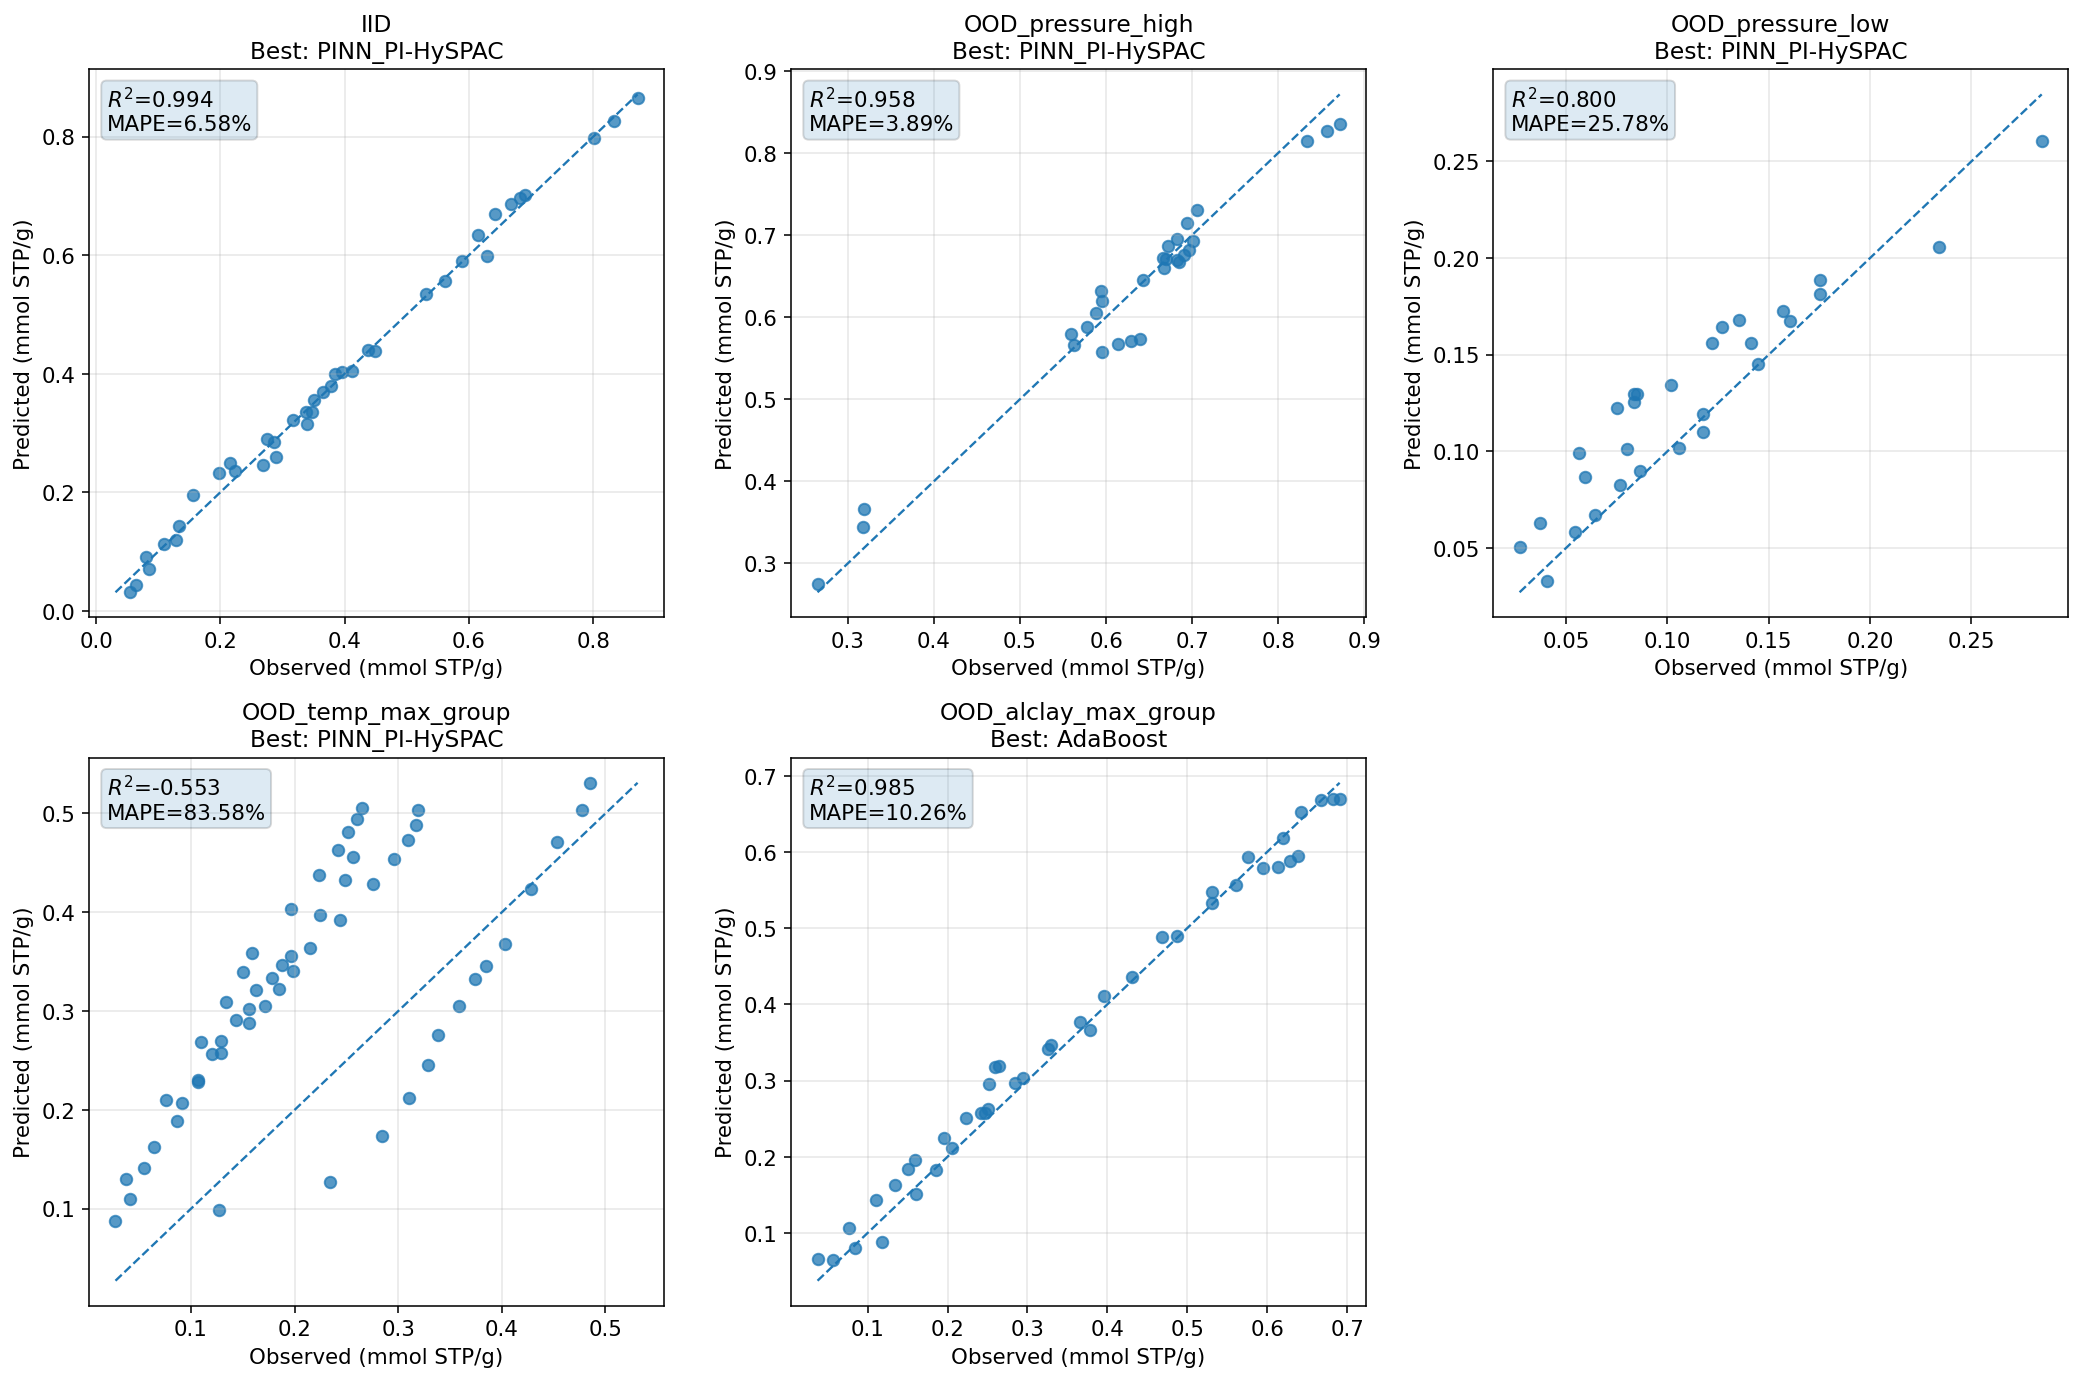

In [85]:
def best_model_from_ci(ci_df, split_name, metric="RMSE", lower_is_better=True):
    sub = ci_df[ci_df["Split"] == split_name].copy()
    col = f"{metric}_mean"
    if lower_is_better:
        return sub.sort_values(col).iloc[0]["Model"]
    else:
        return sub.sort_values(col, ascending=False).iloc[0]["Model"]


# Merge IID and OOD summaries into one selection table
iid_ci_plot = iid_ci_df.copy()
ood_ci_plot = ood_ci_df.copy()
ci_plot_df = pd.concat([iid_ci_plot, ood_ci_plot], axis=0).reset_index(drop=True)

panel_names = ["IID"] + selected_ood_splits

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, split_name in zip(axes, panel_names):
    y_true = parity_predictions[split_name]["y_true"]
    best_model = best_model_from_ci(ci_plot_df, split_name, metric="RMSE", lower_is_better=True)
    y_pred = parity_predictions[split_name][best_model]

    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))

    ax.scatter(y_true, y_pred, s=35, alpha=0.75)
    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.2)

    met = regression_metrics_extended(y_true, y_pred)
    ax.set_title(f"{split_name}\nBest: {best_model}")
    ax.set_xlabel("Observed (mmol STP/g)")
    ax.set_ylabel("Predicted (mmol STP/g)")
    ax.text(
        0.03, 0.97,
        f"$R^2$={met['R2']:.3f}\nMAPE={met['MAPE']:.2f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    ax.grid(True, alpha=0.3)
# Remove unused panels
for j in range(len(panel_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_current_figure("parity_grid_2x3_best_model_per_split")
plt.show()

Saved: figures_PI_HySPAC\parity_grid_2x3_pinn_only.png
Saved: figures_PI_HySPAC\parity_grid_2x3_pinn_only.pdf


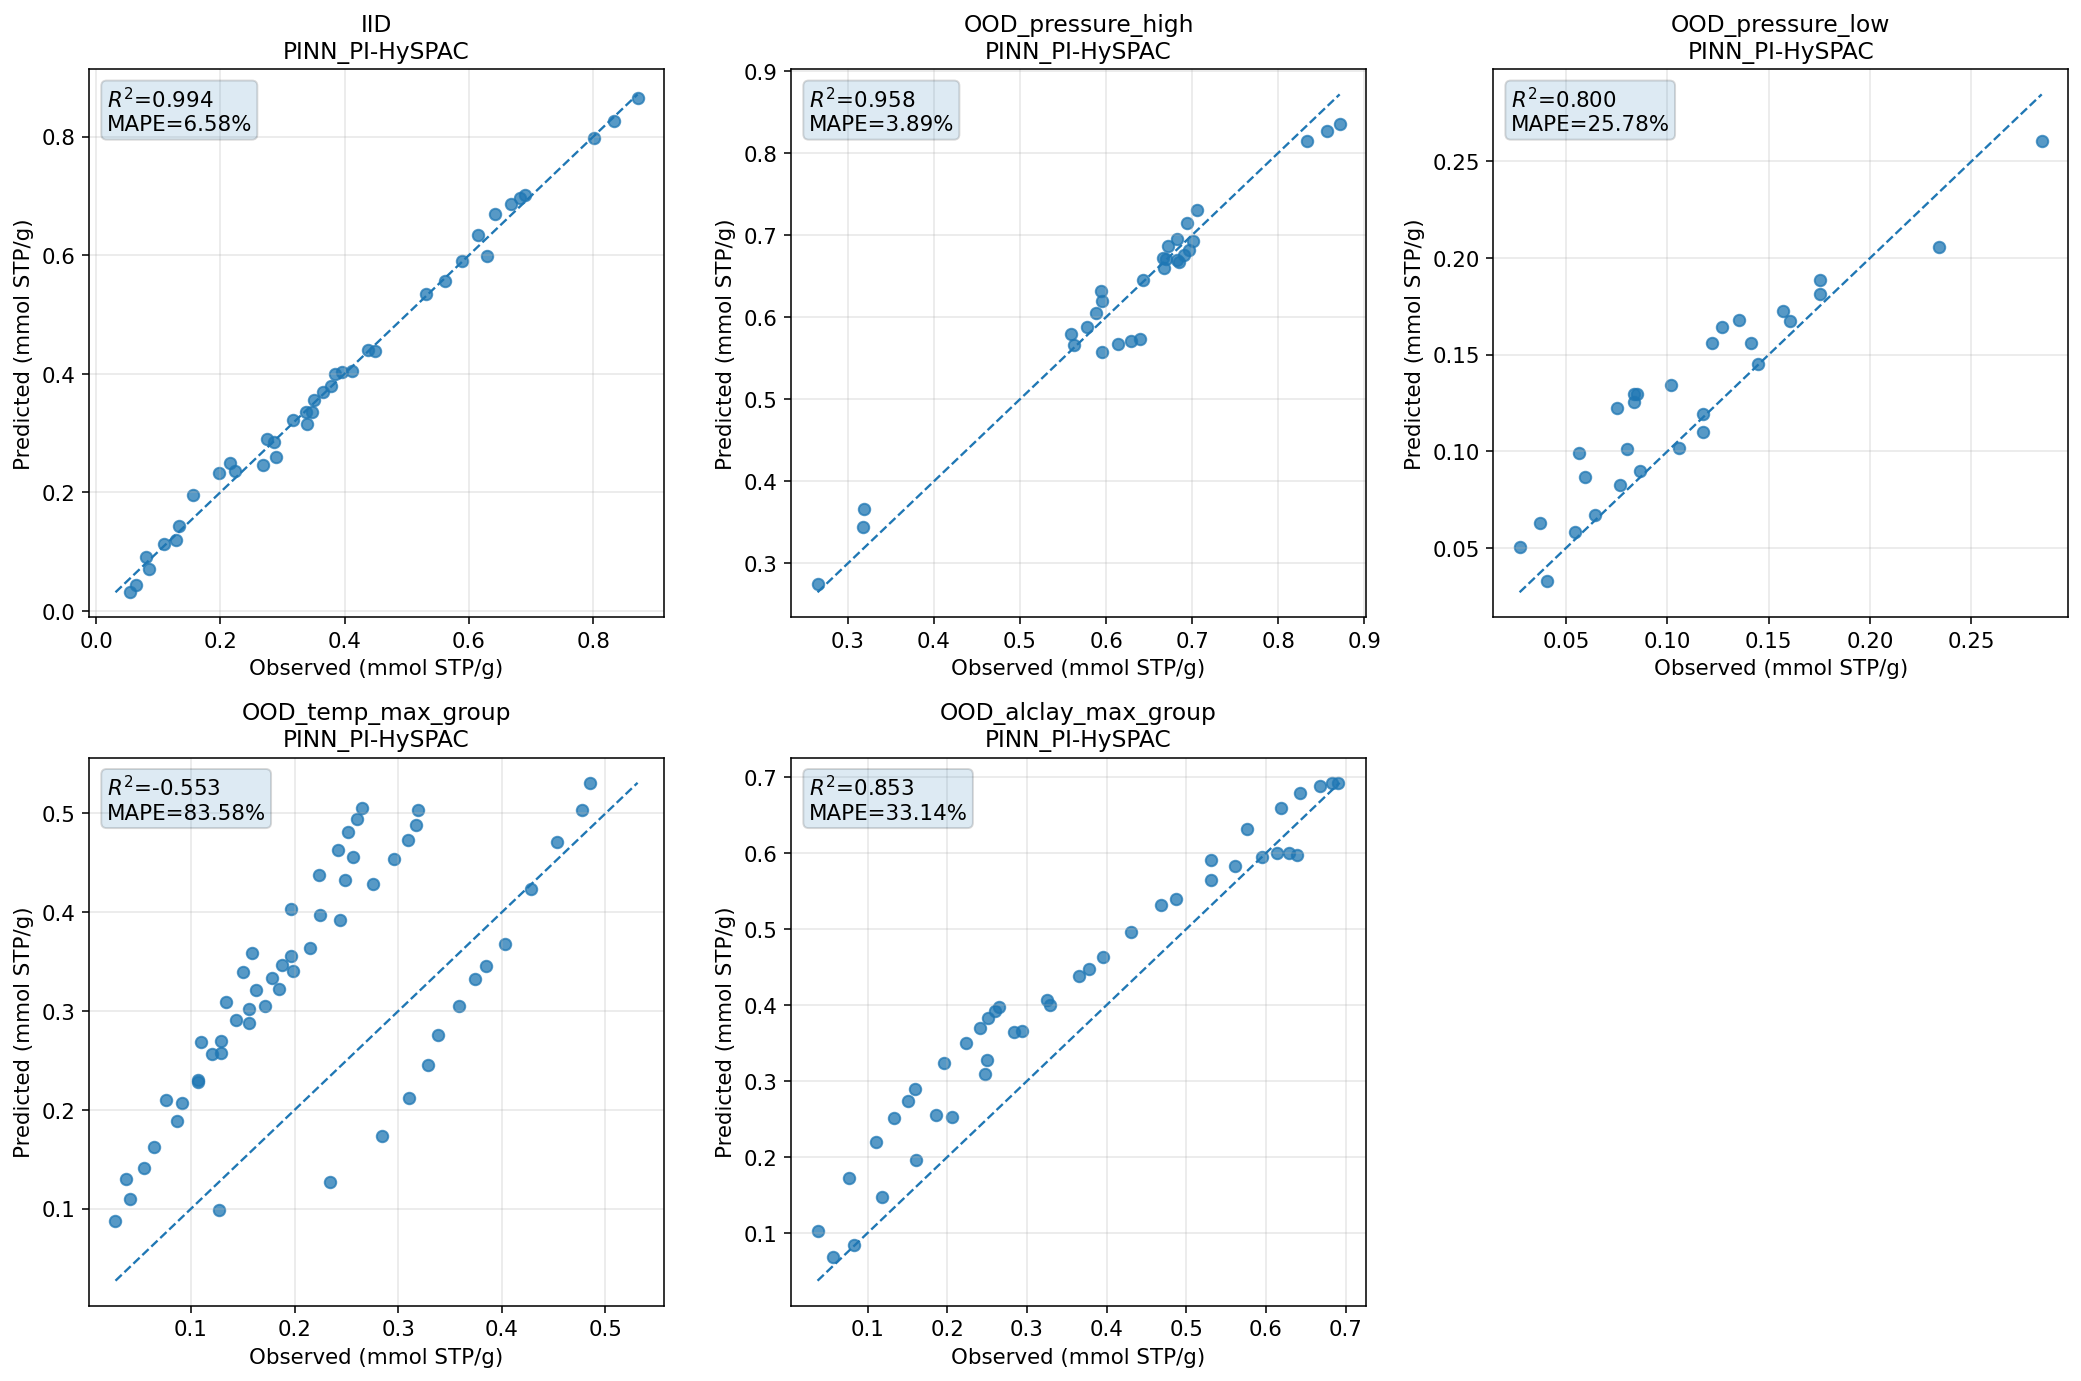

In [86]:
panel_names = ["IID"] + selected_ood_splits

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, split_name in zip(axes, panel_names):
    y_true = parity_predictions[split_name]["y_true"]
    y_pred = parity_predictions[split_name]["PINN_PI-HySPAC"]

    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))

    ax.scatter(y_true, y_pred, s=35, alpha=0.75)
    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.2)

    met = regression_metrics_extended(y_true, y_pred)
    ax.set_title(f"{split_name}\nPINN_PI-HySPAC")
    ax.set_xlabel("Observed (mmol STP/g)")
    ax.set_ylabel("Predicted (mmol STP/g)")
    ax.text(
        0.03, 0.97,
        f"$R^2$={met['R2']:.3f}\nMAPE={met['MAPE']:.2f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    ax.grid(True, alpha=0.3)
# Remove unused panels
for j in range(len(panel_names), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
save_current_figure("parity_grid_2x3_pinn_only")
plt.show()

Best IID model for conformal plot: PINN_PI-HySPAC
Saved: figures_PI_HySPAC\conformal_interval_plot_iid_best_model.png
Saved: figures_PI_HySPAC\conformal_interval_plot_iid_best_model.pdf


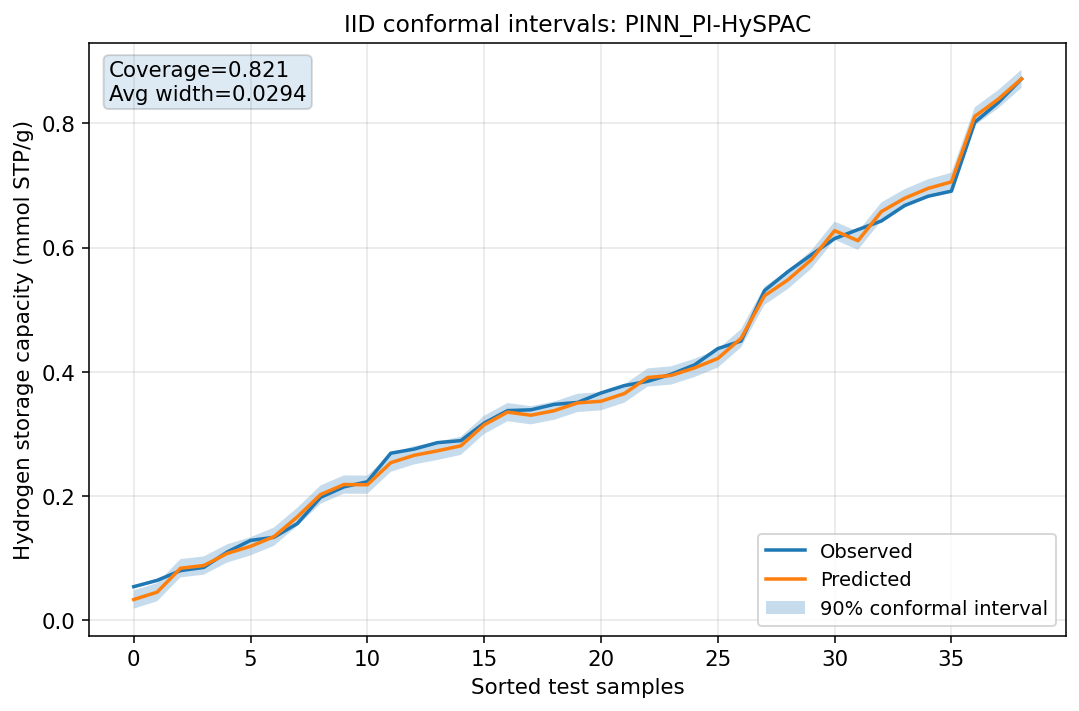

In [87]:
iid_best_model = best_model_from_ci(iid_ci_df, "IID", metric="RMSE", lower_is_better=True)
print("Best IID model for conformal plot:", iid_best_model)

# Recreate conformal intervals for that model
if iid_best_model != "PINN_PI-HySPAC":
    model = {
        "AdaBoost": build_adaboost,
        "GBM": build_gbm,
        "CatBoost": build_catboost,
        "XGBoost": build_xgboost
    }[iid_best_model](baseline_best_params[iid_best_model])

    model.fit(X_train, y_train)
    y_cal_pred = model.predict(X_cal)
    y_test_pred = model.predict(X_test_iid)

else:
    scX = StandardScaler().fit(X_train.values.astype(np.float32))
    scy = StandardScaler().fit(y_train.reshape(-1, 1).astype(np.float32))

    Xtr_s = scX.transform(X_train.values.astype(np.float32))
    Xcal_s = scX.transform(X_cal.values.astype(np.float32))
    Xte_s = scX.transform(X_test_iid.values.astype(np.float32))
    ytr_s = scy.transform(y_train.reshape(-1, 1).astype(np.float32))
    ycal_s = scy.transform(y_cal.reshape(-1, 1).astype(np.float32))

    pinn_model, _, _ = train_pinn_once(
        Xtr_s, ytr_s, Xcal_s, ycal_s,
        params=best_pinn_params,
        verbose=False
    )

    y_cal_pred = predict_pinn(pinn_model, Xcal_s, scy)
    y_test_pred = predict_pinn(pinn_model, Xte_s, scy)

lower, upper, q = conformal_interval_from_calibration(y_cal, y_cal_pred, y_test_pred, alpha=0.10)

order = np.argsort(y_test_iid)
y_obs_sorted = y_test_iid[order]
y_pred_sorted = y_test_pred[order]
lower_sorted = lower[order]
upper_sorted = upper[order]

plt.figure(figsize=(9, 5.5))
x = np.arange(len(y_obs_sorted))

plt.plot(x, y_obs_sorted, linewidth=1.8, label="Observed")
plt.plot(x, y_pred_sorted, linewidth=1.8, label="Predicted")
plt.fill_between(x, lower_sorted, upper_sorted, alpha=0.25, label="90% conformal interval")

coverage = prediction_interval_coverage(y_test_iid, lower, upper)
avg_width = mean_interval_width(lower, upper)

plt.xlabel("Sorted test samples")
plt.ylabel("Hydrogen storage capacity (mmol STP/g)")
plt.title(f"IID conformal intervals: {iid_best_model}")
plt.text(
    0.02, 0.97,
    f"Coverage={coverage:.3f}\nAvg width={avg_width:.4f}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
)
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure("conformal_interval_plot_iid_best_model")
plt.show()

In [75]:
def build_metric_plot_df(iid_ci_df, ood_ci_df, metric):
    iid_part = iid_ci_df.copy()
    ood_part = ood_ci_df.copy()

    iid_part["Group"] = "IID"
    ood_part["Group"] = "OOD"

    # Aggregate OOD across splits by averaging split-level means
    ood_agg_rows = []
    for model_name, sub in ood_part.groupby("Model"):
        vals = sub[f"{metric}_mean"].values
        mean_val = np.mean(vals)
        std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
        se_val = std_val / np.sqrt(len(vals)) if len(vals) > 0 else 0.0
        ci95 = 1.96 * se_val

        ood_agg_rows.append({
            "Model": model_name,
            "Group": "OOD",
            f"{metric}_mean": mean_val,
            f"{metric}_ci95": ci95
        })

    ood_agg = pd.DataFrame(ood_agg_rows)

    iid_agg_rows = []
    for model_name, sub in iid_part.groupby("Model"):
        iid_agg_rows.append({
            "Model": model_name,
            "Group": "IID",
            f"{metric}_mean": sub[f"{metric}_mean"].iloc[0],
            f"{metric}_ci95": sub[f"{metric}_ci95"].iloc[0]
        })

    iid_agg = pd.DataFrame(iid_agg_rows)

    return pd.concat([iid_agg, ood_agg], axis=0).reset_index(drop=True)


plot_r2_df = build_metric_plot_df(iid_ci_df, ood_ci_df, "R2")
plot_mape_df = build_metric_plot_df(iid_ci_df, ood_ci_df, "MAPE")

plot_r2_df, plot_mape_df

(            Model Group   R2_mean   R2_ci95
 0        AdaBoost   IID  0.961646  0.009462
 1        CatBoost   IID  0.990524  0.001354
 2             GBM   IID  0.980575  0.003733
 3  PINN_PI-HySPAC   IID  0.994970  0.000887
 4         XGBoost   IID  0.977711  0.003954
 5        AdaBoost   OOD  0.015897  0.978112
 6        CatBoost   OOD  0.047538  1.014678
 7             GBM   OOD  0.128285  0.767451
 8  PINN_PI-HySPAC   OOD  0.512298  0.651220
 9         XGBoost   OOD  0.044217  0.955593,
             Model Group  MAPE_mean  MAPE_ci95
 0        AdaBoost   IID  11.391398   1.141629
 1        CatBoost   IID   6.641300   0.864989
 2             GBM   IID   7.717955   0.674353
 3  PINN_PI-HySPAC   IID   5.398502   0.811536
 4         XGBoost   IID   8.932462   0.995635
 5        AdaBoost   OOD  44.852623  40.174584
 6        CatBoost   OOD  44.044906  39.663553
 7             GBM   OOD  43.728683  35.250240
 8  PINN_PI-HySPAC   OOD  37.625014  31.028944
 9         XGBoost   OOD  47.13715

In [77]:
def build_metric_plot_df(iid_ci_df, ood_ci_df, metric):
    iid_part = iid_ci_df.copy()
    ood_part = ood_ci_df.copy()

    iid_part["Group"] = "IID"
    ood_part["Group"] = "OOD"

    # Aggregate OOD across splits by averaging split-level means
    ood_agg_rows = []
    for model_name, sub in ood_part.groupby("Model"):
        vals = sub[f"{metric}_mean"].values
        mean_val = np.mean(vals)
        std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
        se_val = std_val / np.sqrt(len(vals)) if len(vals) > 0 else 0.0
        ci95 = 1.96 * se_val

        ood_agg_rows.append({
            "Model": model_name,
            "Group": "OOD",
            f"{metric}_mean": mean_val,
            f"{metric}_ci95": ci95
        })

    ood_agg = pd.DataFrame(ood_agg_rows)

    iid_agg_rows = []
    for model_name, sub in iid_part.groupby("Model"):
        iid_agg_rows.append({
            "Model": model_name,
            "Group": "IID",
            f"{metric}_mean": sub[f"{metric}_mean"].iloc[0],
            f"{metric}_ci95": sub[f"{metric}_ci95"].iloc[0]
        })

    iid_agg = pd.DataFrame(iid_agg_rows)

    return pd.concat([iid_agg, ood_agg], axis=0).reset_index(drop=True)


plot_r2_df = build_metric_plot_df(iid_ci_df, ood_ci_df, "R2")
plot_mape_df = build_metric_plot_df(iid_ci_df, ood_ci_df, "MAPE")

plot_r2_df, plot_mape_df

(            Model Group   R2_mean   R2_ci95
 0        AdaBoost   IID  0.961646  0.009462
 1        CatBoost   IID  0.990524  0.001354
 2             GBM   IID  0.980575  0.003733
 3  PINN_PI-HySPAC   IID  0.994970  0.000887
 4         XGBoost   IID  0.977711  0.003954
 5        AdaBoost   OOD  0.015897  0.978112
 6        CatBoost   OOD  0.047538  1.014678
 7             GBM   OOD  0.128285  0.767451
 8  PINN_PI-HySPAC   OOD  0.512298  0.651220
 9         XGBoost   OOD  0.044217  0.955593,
             Model Group  MAPE_mean  MAPE_ci95
 0        AdaBoost   IID  11.391398   1.141629
 1        CatBoost   IID   6.641300   0.864989
 2             GBM   IID   7.717955   0.674353
 3  PINN_PI-HySPAC   IID   5.398502   0.811536
 4         XGBoost   IID   8.932462   0.995635
 5        AdaBoost   OOD  44.852623  40.174584
 6        CatBoost   OOD  44.044906  39.663553
 7             GBM   OOD  43.728683  35.250240
 8  PINN_PI-HySPAC   OOD  37.625014  31.028944
 9         XGBoost   OOD  47.13715

Saved: figures_PI_HySPAC\metrics_grid_1x2_r2_mape_ci.png
Saved: figures_PI_HySPAC\metrics_grid_1x2_r2_mape_ci.pdf


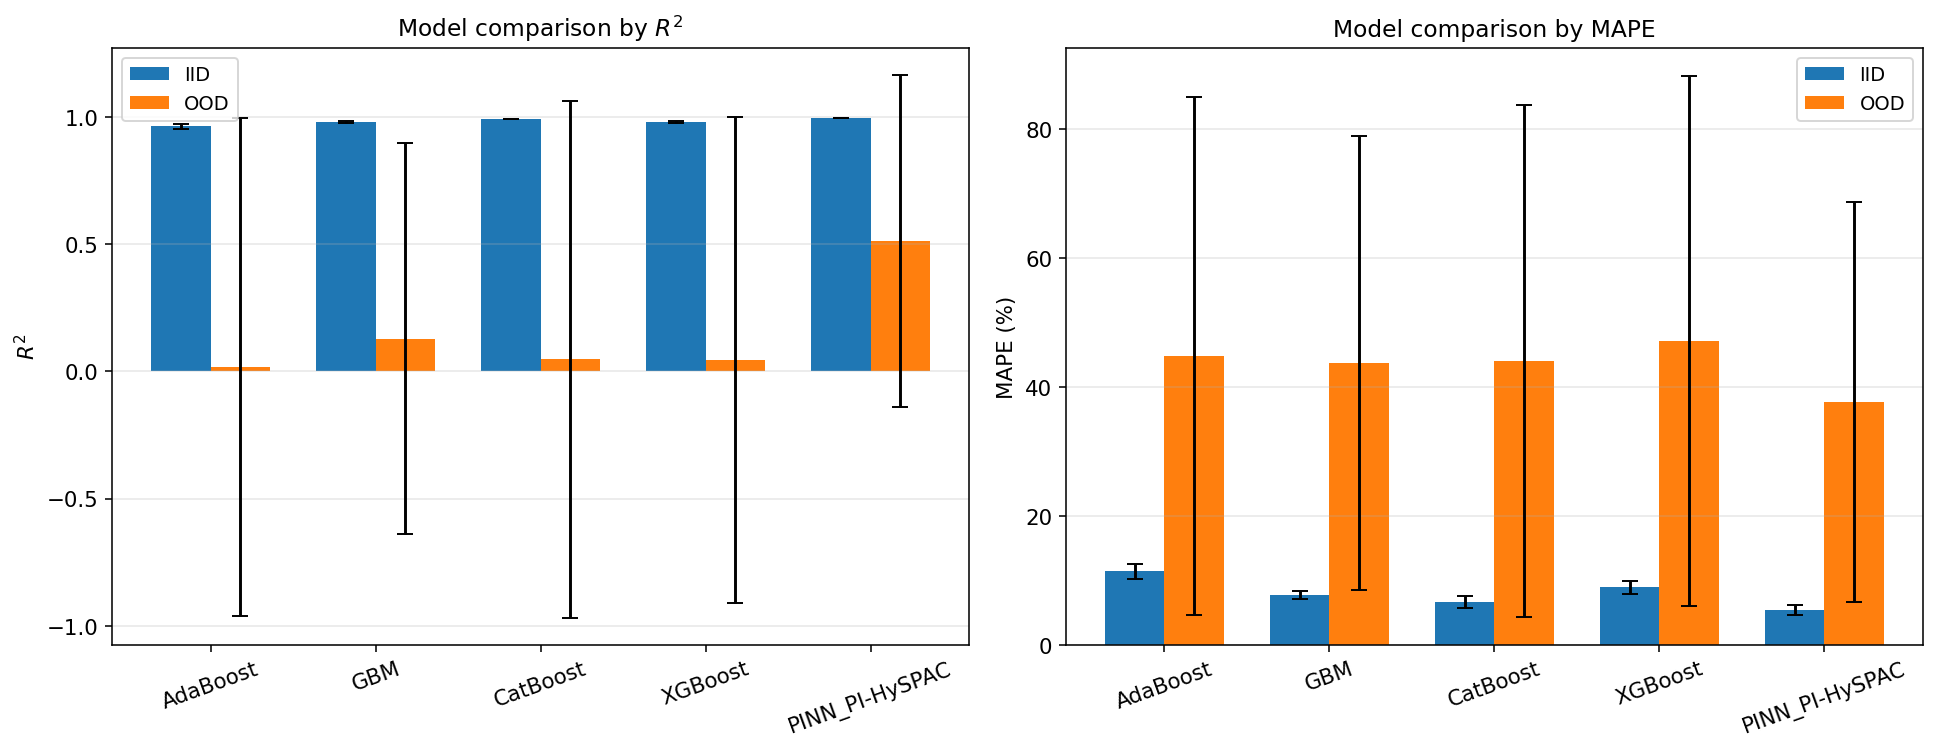

In [78]:
model_order = ["AdaBoost", "GBM", "CatBoost", "XGBoost", "PINN_PI-HySPAC"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- R2 ---
ax = axes[0]
x = np.arange(len(model_order))
width = 0.36

iid_sub = plot_r2_df.set_index(["Group", "Model"])
iid_means = [iid_sub.loc[("IID", m), "R2_mean"] for m in model_order]
iid_cis = [iid_sub.loc[("IID", m), "R2_ci95"] for m in model_order]
ood_means = [iid_sub.loc[("OOD", m), "R2_mean"] for m in model_order]
ood_cis = [iid_sub.loc[("OOD", m), "R2_ci95"] for m in model_order]

ax.bar(x - width/2, iid_means, width=width, yerr=iid_cis, capsize=4, label="IID")
ax.bar(x + width/2, ood_means, width=width, yerr=ood_cis, capsize=4, label="OOD")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=20)
ax.set_ylabel("$R^2$")
ax.set_title("Model comparison by $R^2$")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# --- MAPE ---
ax = axes[1]
iid_sub = plot_mape_df.set_index(["Group", "Model"])
iid_means = [iid_sub.loc[("IID", m), "MAPE_mean"] for m in model_order]
iid_cis = [iid_sub.loc[("IID", m), "MAPE_ci95"] for m in model_order]
ood_means = [iid_sub.loc[("OOD", m), "MAPE_mean"] for m in model_order]
ood_cis = [iid_sub.loc[("OOD", m), "MAPE_ci95"] for m in model_order]

ax.bar(x - width/2, iid_means, width=width, yerr=iid_cis, capsize=4, label="IID")
ax.bar(x + width/2, ood_means, width=width, yerr=ood_cis, capsize=4, label="OOD")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=20)
ax.set_ylabel("MAPE (%)")
ax.set_title("Model comparison by MAPE")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_current_figure("metrics_grid_1x2_r2_mape_ci")
plt.show()

Saved: figures_PI_HySPAC\metric_r2_by_split_ci.png
Saved: figures_PI_HySPAC\metric_r2_by_split_ci.pdf


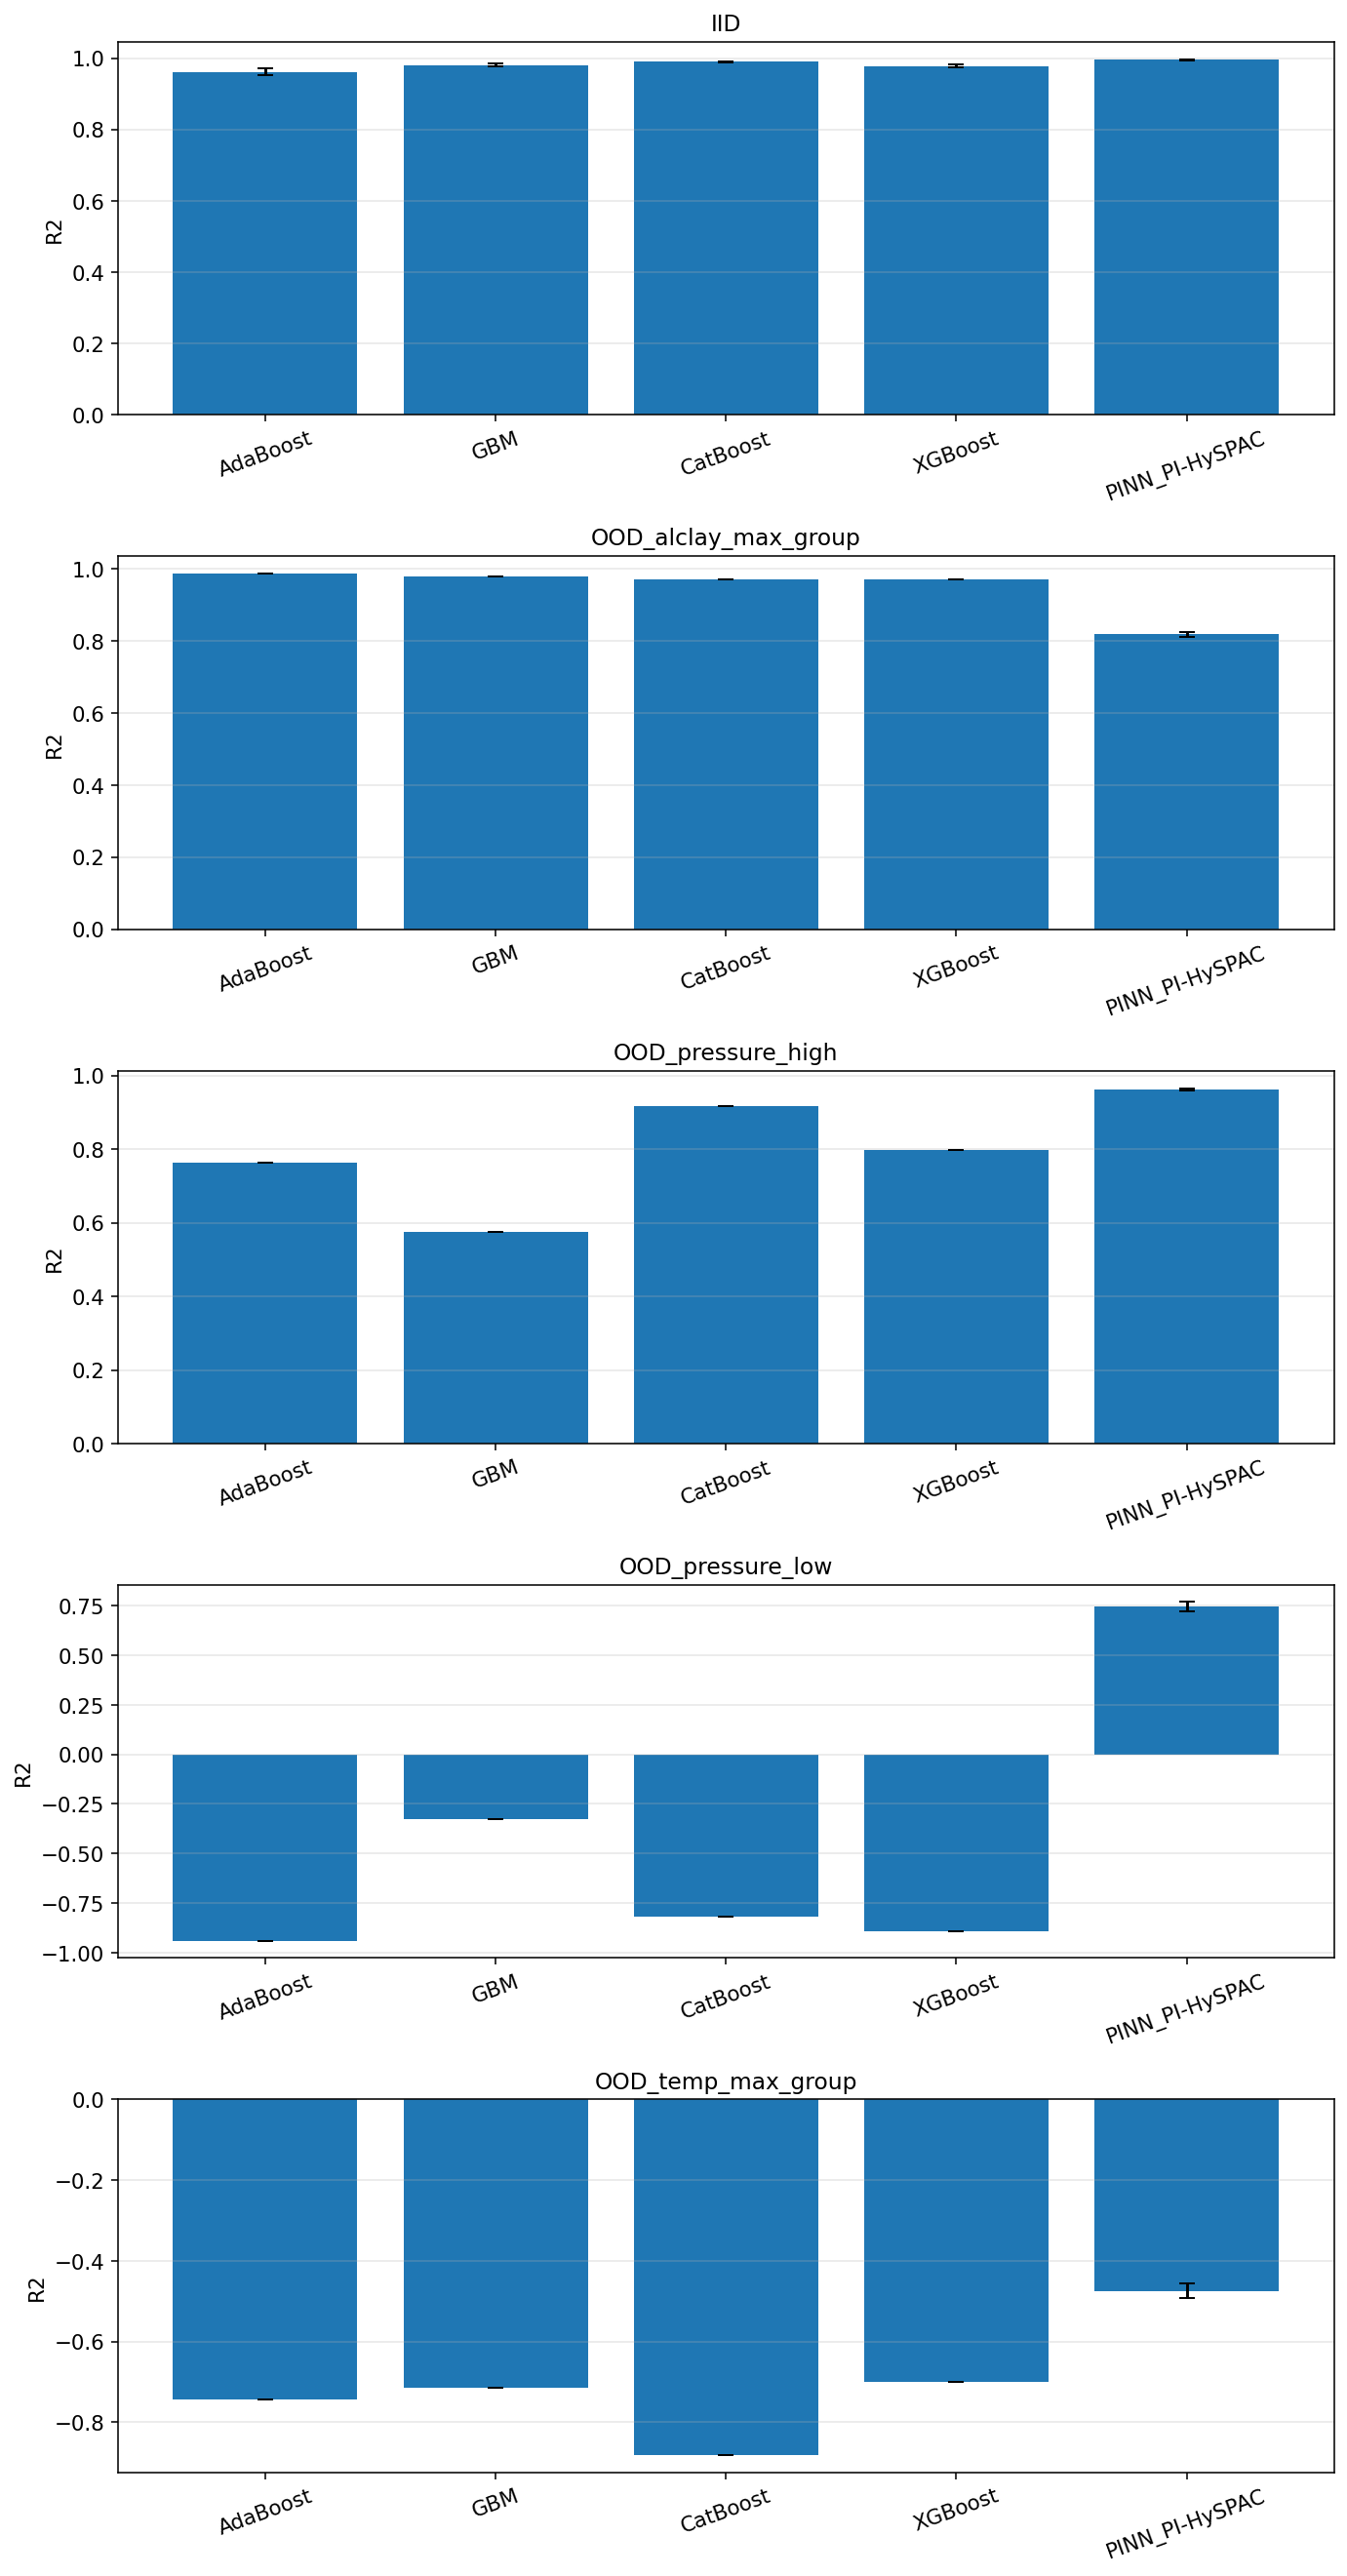

Saved: figures_PI_HySPAC\metric_mape_by_split_ci.png
Saved: figures_PI_HySPAC\metric_mape_by_split_ci.pdf


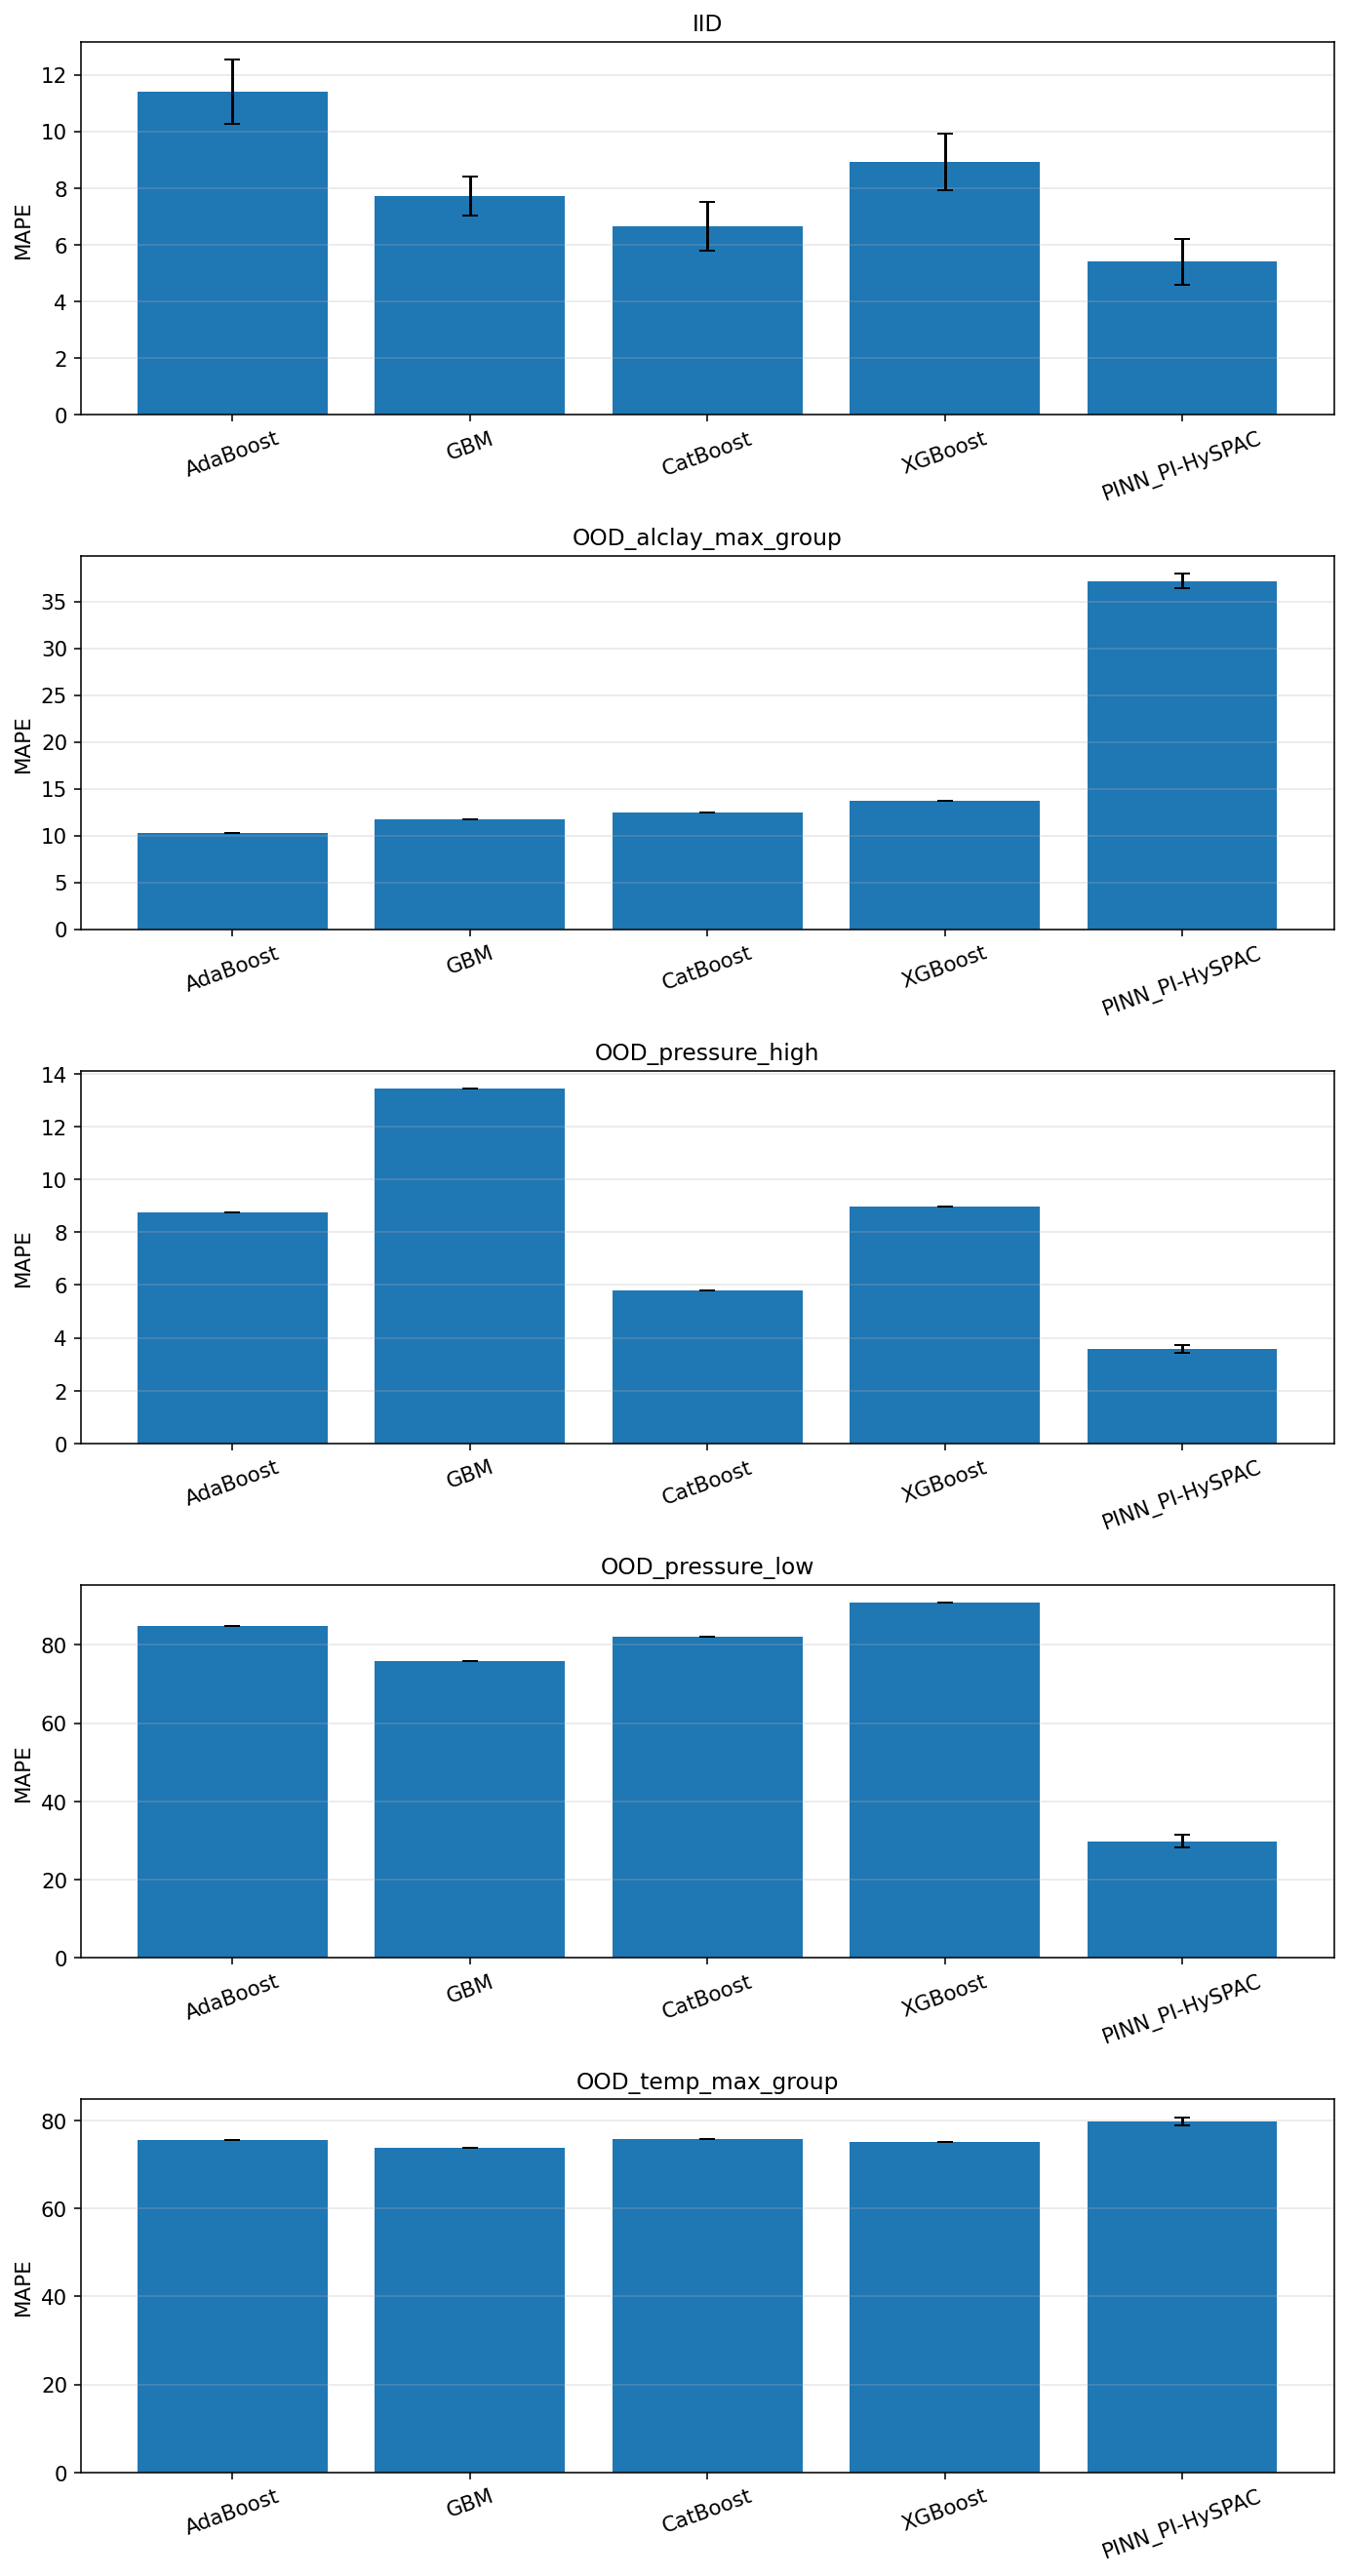

In [79]:
def plot_metric_by_split(ci_df, metric, higher_is_better=False):
    splits = ci_df["Split"].unique()
    fig, axes = plt.subplots(len(splits), 1, figsize=(10, 3.8 * len(splits)))

    if len(splits) == 1:
        axes = [axes]

    for ax, split_name in zip(axes, splits):
        sub = ci_df[ci_df["Split"] == split_name].copy()

        sub = sub.set_index("Model").reindex(model_order).reset_index()
        x = np.arange(len(sub))

        ax.bar(
            x,
            sub[f"{metric}_mean"],
            yerr=sub[f"{metric}_ci95"],
            capsize=4
        )
        ax.set_xticks(x)
        ax.set_xticklabels(sub["Model"], rotation=20)
        ax.set_ylabel(metric)
        ax.set_title(split_name)
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    save_current_figure(f"metric_{metric.lower()}_by_split_ci")
    plt.show()


plot_metric_by_split(pd.concat([iid_ci_df, ood_ci_df], axis=0), "R2")
plot_metric_by_split(pd.concat([iid_ci_df, ood_ci_df], axis=0), "MAPE")